In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import os

Mounted at /content/drive


In [2]:
data_path = "/content/drive/MyDrive/Disstertaion/data"

os.listdir(data_path)

['pp-2020.csv',
 'pp-2026.csv',
 'pp-2021.csv',
 'pp-2023.csv',
 'pp-2022.csv',
 'pp-2024.csv',
 'pp-2025 (1).csv',
 'Bank_Rate.csv',
 'UK-HPI-full-file.csv',
 'labour_market_rate.xlsx',
 'final_model_data.csv',
 'model_results.csv',
 'regression_pipeline_diagram.png',
 'linear_regression_coefficients.png',
 'price_paid_clean.csv',
 'linear_regression_coefficients.csv',
 'eda_average_house_price_over_time.csv',
 'final_model_data_cleaned.csv',
 'bank_rate_monthly_clean.csv',
 'hpi_clean.csv',
 'labour_market_clean.csv',
 'hpi_bank_merged.csv',
 'EDA_descriptive_statistics.csv',
 'eda_average_house_price_over_time.png',
 'eda_bank_rate_over_time.png',
 'eda_average_house_price_by_region.png',
 'eda_labour_market_indicators.png',
 'model_data_proposal_features.csv',
 'correlation_matrix_heatmap.png',
 'target_price_correlations.png',
 'target_price_correlations.csv',
 'regression_model_comparison_rmse.png',
 'regional_error_analysis.csv',
 'actual_vs_predicted.png',
 'pipeline_regression

In [3]:
hpi = pd.read_csv(data_path + "/UK-HPI-full-file.csv")
bank_rate = pd.read_csv(data_path + "/Bank_Rate.csv")
labour = pd.read_excel(data_path + "/labour_market_rate.xlsx")
pp_2020 = pd.read_csv(data_path + "/pp-2020.csv", header=None)

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [4]:
hpi = pd.read_csv(data_path + "/UK-HPI-full-file.csv")

hpi.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [5]:
hpi.shape

(150705, 54)

In [6]:
hpi.columns

Index(['Date', 'RegionName', 'AreaCode', 'AveragePrice', 'Index', 'IndexSA',
       '1m%Change', '12m%Change', 'AveragePriceSA', 'SalesVolume',
       'DetachedPrice', 'DetachedIndex', 'Detached1m%Change',
       'Detached12m%Change', 'SemiDetachedPrice', 'SemiDetachedIndex',
       'SemiDetached1m%Change', 'SemiDetached12m%Change', 'TerracedPrice',
       'TerracedIndex', 'Terraced1m%Change', 'Terraced12m%Change', 'FlatPrice',
       'FlatIndex', 'Flat1m%Change', 'Flat12m%Change', 'CashPrice',
       'CashIndex', 'Cash1m%Change', 'Cash12m%Change', 'CashSalesVolume',
       'MortgagePrice', 'MortgageIndex', 'Mortgage1m%Change',
       'Mortgage12m%Change', 'MortgageSalesVolume', 'FTBPrice', 'FTBIndex',
       'FTB1m%Change', 'FTB12m%Change', 'FOOPrice', 'FOOIndex', 'FOO1m%Change',
       'FOO12m%Change', 'NewPrice', 'NewIndex', 'New1m%Change',
       'New12m%Change', 'NewSalesVolume', 'OldPrice', 'OldIndex',
       'Old1m%Change', 'Old12m%Change', 'OldSalesVolume'],
      dtype='object

In [7]:
bank_rate = pd.read_csv(data_path + "/Bank_Rate.csv")
bank_rate.head()

,Date Changed,Rate
0,18 Dec 25,3.75
1,07 Aug 25,4.00
2,08 May 25,4.25
3,06 Feb 25,4.50
4,07 Nov 24,4.75


In [8]:
bank_rate.shape

(258, 2)

In [9]:
bank_rate.columns

Index(['Date Changed', 'Rate'], dtype='object')

In [10]:
labour = pd.read_excel(data_path + "/labour_market_rate.xlsx")

labour.head(20)

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,labour force survey - national and regional - headline indicators (seasonally adjusted),Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,ONS Crown Copyright Reserved [from Nomis on 30...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,sex,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,economic activity,Total economically active - aged 16 to 64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,value type,Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Date,East,East Midlands,London,North East,North West,Northern Ireland,Scotland,South East,South West,Wales,West Midlands,Yorkshire and The Humber
7,Nov 2014-Jan 2015,80.7,78.1,77.2,75.8,75.9,72,78.6,80.3,80.2,74.5,76.5,77.1
8,Dec 2014-Feb 2015,80.6,78.3,77.2,75.5,76.1,73,79.1,80.5,80.7,74.4,76,77.1
9,Jan 2015-Mar 2015,80.5,77.8,77,74.7,76,72.9,79.4,80.6,80.9,74.5,76.3,76.8


In [11]:
labour.shape

(447, 13)

In [12]:
labour.columns

Index(['labour force survey - national and regional - headline indicators (seasonally adjusted)',
       'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5',
       'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10',
       'Unnamed: 11', 'Unnamed: 12'],
      dtype='object')

In [13]:
pp_2020 = pd.read_csv(data_path + "/pp-2020.csv", header=None)

pp_2020.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A


In [14]:
pp_2020.shape

(897565, 16)

# Data Cleaning

House Price Index

In [15]:
hpi_clean = hpi.copy()
hpi_clean.head()

,Date,RegionName,AreaCode,AveragePrice,Index,IndexSA,1m%Change,12m%Change,AveragePriceSA,SalesVolume,...,NewPrice,NewIndex,New1m%Change,New12m%Change,NewSalesVolume,OldPrice,OldIndex,Old1m%Change,Old12m%Change,OldSalesVolume
0,01/01/2004,Aberdeenshire,S12000034,84638,41.1,NaN,NaN,NaN,NaN,388.0,...,112843.0,40.7,NaN,NaN,103.0,81273.0,41.0,NaN,NaN,285.0
1,01/02/2004,Aberdeenshire,S12000034,84623,41.1,NaN,0.0,NaN,NaN,326.0,...,113061.0,40.8,0.2,NaN,107.0,81194.0,40.9,-0.1,NaN,219.0
2,01/03/2004,Aberdeenshire,S12000034,86536,42.1,NaN,2.3,NaN,NaN,453.0,...,115218.0,41.6,1.9,NaN,140.0,83137.0,41.9,2.4,NaN,313.0
3,01/04/2004,Aberdeenshire,S12000034,87373,42.5,NaN,1.0,NaN,NaN,571.0,...,115247.0,41.6,0.0,NaN,180.0,84241.0,42.5,1.3,NaN,391.0
4,01/05/2004,Aberdeenshire,S12000034,89493,43.5,NaN,2.4,NaN,NaN,502.0,...,117377.0,42.4,1.8,NaN,167.0,86466.0,43.6,2.6,NaN,335.0


In [16]:
hpi_clean["Date"] = pd.to_datetime(hpi_clean["Date"], errors="coerce")

hpi_clean["year"] = hpi_clean["Date"].dt.year
hpi_clean["month"] = hpi_clean["Date"].dt.month
hpi_clean["year_month"] = hpi_clean["Date"].dt.to_period("M").astype(str)

hpi_clean[["Date", "year", "month", "year_month"]].head()

,Date,year,month,year_month
0,2004-01-01,2004,1,2004-01
1,2004-01-02,2004,1,2004-01
2,2004-01-03,2004,1,2004-01
3,2004-01-04,2004,1,2004-01
4,2004-01-05,2004,1,2004-01


In [17]:
hpi_clean = hpi_clean[hpi_clean["year"] >= 2015]

hpi_clean.shape

(55080, 57)

In [18]:
hpi_clean = hpi_clean[
    [
        "year_month",
        "year",
        "month",
        "Date",
        "RegionName",
        "AreaCode",
        "AveragePrice",
        "Index",
        "SalesVolume",
        "DetachedPrice",
        "SemiDetachedPrice",
        "TerracedPrice",
        "FlatPrice",
        "CashPrice",
        "MortgagePrice"
    ]
]

hpi_clean.head()

,year_month,year,month,Date,RegionName,AreaCode,AveragePrice,Index,SalesVolume,DetachedPrice,SemiDetachedPrice,TerracedPrice,FlatPrice,CashPrice,MortgagePrice
132,2015-01,2015,1,2015-01-01,Aberdeenshire,S12000034,207121,100.7,372.0,299512.0,181207.0,152059.0,116233.0,192989.0,214830.0
133,2015-01,2015,1,2015-01-02,Aberdeenshire,S12000034,206254,100.2,305.0,298765.0,180357.0,151213.0,115364.0,191911.0,214028.0
134,2015-01,2015,1,2015-01-03,Aberdeenshire,S12000034,209080,101.6,437.0,306526.0,181328.0,151594.0,115507.0,194107.0,217109.0
135,2015-01,2015,1,2015-01-04,Aberdeenshire,S12000034,209871,102.0,395.0,304708.0,183316.0,153605.0,117328.0,195237.0,217791.0
136,2015-01,2015,1,2015-01-05,Aberdeenshire,S12000034,208779,101.5,405.0,300927.0,183463.0,153664.0,117669.0,194487.0,216562.0


In [19]:
hpi_clean = hpi_clean.rename(columns={
    "Date": "date",
    "RegionName": "region",
    "AreaCode": "area_code",
    "AveragePrice": "average_price",
    "Index": "house_price_index",
    "SalesVolume": "sales_volume",
    "DetachedPrice": "detached_price",
    "SemiDetachedPrice": "semi_detached_price",
    "TerracedPrice": "terraced_price",
    "FlatPrice": "flat_price",
    "CashPrice": "cash_price",
    "MortgagePrice": "mortgage_price"
})

hpi_clean.head()

,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,semi_detached_price,terraced_price,flat_price,cash_price,mortgage_price
132,2015-01,2015,1,2015-01-01,Aberdeenshire,S12000034,207121,100.7,372.0,299512.0,181207.0,152059.0,116233.0,192989.0,214830.0
133,2015-01,2015,1,2015-01-02,Aberdeenshire,S12000034,206254,100.2,305.0,298765.0,180357.0,151213.0,115364.0,191911.0,214028.0
134,2015-01,2015,1,2015-01-03,Aberdeenshire,S12000034,209080,101.6,437.0,306526.0,181328.0,151594.0,115507.0,194107.0,217109.0
135,2015-01,2015,1,2015-01-04,Aberdeenshire,S12000034,209871,102.0,395.0,304708.0,183316.0,153605.0,117328.0,195237.0,217791.0
136,2015-01,2015,1,2015-01-05,Aberdeenshire,S12000034,208779,101.5,405.0,300927.0,183463.0,153664.0,117669.0,194487.0,216562.0


In [20]:
hpi_clean.isnull().sum()

,0
year_month,0
year,0
month,0
date,0
region,0
area_code,0
average_price,0
house_price_index,0
sales_volume,810
detached_price,1632


In [21]:
hpi_clean.to_csv(data_path + "/hpi_clean.csv", index=False)

Bank Rate

In [22]:
bank_clean = bank_rate.copy()
bank_clean.head()

,Date Changed,Rate
0,18 Dec 25,3.75
1,07 Aug 25,4.00
2,08 May 25,4.25
3,06 Feb 25,4.50
4,07 Nov 24,4.75


In [23]:
bank_clean = bank_clean.rename(columns={
    "Date Changed": "date",
    "Rate": "bank_rate"
})

bank_clean["date"] = pd.to_datetime(bank_clean["date"], errors="coerce")

bank_clean["bank_rate"] = pd.to_numeric(bank_clean["bank_rate"], errors="coerce")

bank_clean.head()

/tmp/ipykernel_1063/2421759569.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bank_clean["date"] = pd.to_datetime(bank_clean["date"], errors="coerce")


,date,bank_rate
0,2025-12-18,3.75
1,2025-08-07,4.00
2,2025-05-08,4.25
3,2025-02-06,4.50
4,2024-11-07,4.75


In [24]:
bank_clean["year"] = bank_clean["date"].dt.year
bank_clean["month"] = bank_clean["date"].dt.month
bank_clean["year_month"] = bank_clean["date"].dt.to_period("M").astype(str)

bank_clean.head()

,date,bank_rate,year,month,year_month
0,2025-12-18,3.75,2025,12,2025-12
1,2025-08-07,4.00,2025,8,2025-08
2,2025-05-08,4.25,2025,5,2025-05
3,2025-02-06,4.50,2025,2,2025-02
4,2024-11-07,4.75,2024,11,2024-11


In [25]:
#bank_clean = bank_clean[bank_clean["year"] >= 2015]

bank_clean.shape

(258, 5)

In [26]:
bank_clean = bank_clean[
    [
        "date",
        "year",
        "month",
        "year_month",
        "bank_rate"
    ]
]

bank_clean.head()

,date,year,month,year_month,bank_rate
0,2025-12-18,2025,12,2025-12,3.75
1,2025-08-07,2025,8,2025-08,4.00
2,2025-05-08,2025,5,2025-05,4.25
3,2025-02-06,2025,2,2025-02,4.50
4,2024-11-07,2024,11,2024-11,4.75


Note - Bank rate only changes on some dates, not every month. But Hpi data is monthly. So it need to create a monthly bank rate table.

In [27]:
monthly_dates = pd.DataFrame({
    "date": pd.date_range(
        start=hpi_clean["date"].min(),
        end=hpi_clean["date"].max(),
        freq="MS"
    )
})

bank_clean = bank_clean.sort_values("date")

bank_monthly = pd.merge_asof(
    monthly_dates.sort_values("date"),
    bank_clean[["date", "bank_rate"]].sort_values("date"),
    on="date",
    direction="backward"
)

bank_monthly["year"] = bank_monthly["date"].dt.year
bank_monthly["month"] = bank_monthly["date"].dt.month
bank_monthly["year_month"] = bank_monthly["date"].dt.to_period("M").astype(str)

bank_monthly.head()

,date,bank_rate,year,month,year_month
0,2015-01-01,0.5,2015,1,2015-01
1,2015-02-01,0.5,2015,2,2015-02
2,2015-03-01,0.5,2015,3,2015-03
3,2015-04-01,0.5,2015,4,2015-04
4,2015-05-01,0.5,2015,5,2015-05


In [28]:
bank_monthly.isnull().sum()

,0
date,0
bank_rate,0
year,0
month,0
year_month,0


In [29]:
bank_monthly.to_csv(data_path + "/bank_rate_monthly_clean.csv", index=False)

Merge UK House Price Index (HPI) + Bank Rate.


So each house price row will get the
correct interest rate for that month.

In [30]:
hpi_bank = pd.merge(
    hpi_clean,
    bank_monthly[["year_month", "bank_rate"]],
    on="year_month",
    how="left"
)

hpi_bank.head()

,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,semi_detached_price,terraced_price,flat_price,cash_price,mortgage_price,bank_rate
0,2015-01,2015,1,2015-01-01,Aberdeenshire,S12000034,207121,100.7,372.0,299512.0,181207.0,152059.0,116233.0,192989.0,214830.0,0.5
1,2015-01,2015,1,2015-01-02,Aberdeenshire,S12000034,206254,100.2,305.0,298765.0,180357.0,151213.0,115364.0,191911.0,214028.0,0.5
2,2015-01,2015,1,2015-01-03,Aberdeenshire,S12000034,209080,101.6,437.0,306526.0,181328.0,151594.0,115507.0,194107.0,217109.0,0.5
3,2015-01,2015,1,2015-01-04,Aberdeenshire,S12000034,209871,102.0,395.0,304708.0,183316.0,153605.0,117328.0,195237.0,217791.0,0.5
4,2015-01,2015,1,2015-01-05,Aberdeenshire,S12000034,208779,101.5,405.0,300927.0,183463.0,153664.0,117669.0,194487.0,216562.0,0.5


In [31]:
hpi_bank.shape

(55080, 16)

In [32]:
hpi_bank.isnull().sum()

,0
year_month,0
year,0
month,0
date,0
region,0
area_code,0
average_price,0
house_price_index,0
sales_volume,810
detached_price,1632


In [33]:
hpi_bank[
    [
        "year_month",
        "region",
        "average_price",
        "house_price_index",
        "sales_volume",
        "bank_rate"
    ]
].head(20)

,year_month,region,average_price,house_price_index,sales_volume,bank_rate
0,2015-01,Aberdeenshire,207121,100.7,372.0,0.5
1,2015-01,Aberdeenshire,206254,100.2,305.0,0.5
2,2015-01,Aberdeenshire,209080,101.6,437.0,0.5
3,2015-01,Aberdeenshire,209871,102.0,395.0,0.5
4,2015-01,Aberdeenshire,208779,101.5,405.0,0.5
5,2015-01,Aberdeenshire,203265,98.8,477.0,0.5
6,2015-01,Aberdeenshire,205891,100.1,582.0,0.5
7,2015-01,Aberdeenshire,206636,100.4,398.0,0.5
8,2015-01,Aberdeenshire,209483,101.8,417.0,0.5
9,2015-01,Aberdeenshire,208303,101.2,494.0,0.5


In [34]:
hpi_bank.to_csv(data_path + "/hpi_bank_merged.csv", index=False)

Labour Market

In [35]:
labour_raw = pd.read_excel(data_path + "/labour_market_rate.xlsx", header=None)

labour_raw.head(30)

/usr/local/lib/python3.13/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,0,1,2,3,4,5,6,7,8,9,10,11,12
0,labour force survey - national and regional - ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ONS Crown Copyright Reserved [from Nomis on 30...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sex,Total,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,economic activity,Total economically active - aged 16 to 64,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,value type,Level,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Date,East,East Midlands,London,North East,North West,Northern Ireland,Scotland,South East,South West,Wales,West Midlands,Yorkshire and The Humber
8,Nov 2014-Jan 2015,80.7,78.1,77.2,75.8,75.9,72,78.6,80.3,80.2,74.5,76.5,77.1
9,Dec 2014-Feb 2015,80.6,78.3,77.2,75.5,76.1,73,79.1,80.5,80.7,74.4,76,77.1


In [36]:
date_rows = labour_raw[labour_raw[0].astype(str).str.strip() == "Date"].index.tolist()

date_rows

[7, 157, 307]

Function to convert labour data range into end month.

Then to clean one block, find indicator name above the table, decide column name, region names are on the date row, data starts from next row, keep rows until date becomes empty or another text section starts, keep rows that look like labour date periods, convert wide formate to long format, clean region names, convert date period to year_month, keep useful columns, clean each block and store in a list, show first cleaned block.

In [37]:
def convert_nomis_period(period_text):
    """
    Example:
    'Jan 2015-Mar 2015' becomes '2015-03'
    'Mar 2026-May 2026' becomes '2026-05'
    """
    period_text = str(period_text)

    month_map = {
        "Jan": "01", "Feb": "02", "Mar": "03", "Apr": "04",
        "May": "05", "Jun": "06", "Jul": "07", "Aug": "08",
        "Sep": "09", "Oct": "10", "Nov": "11", "Dec": "12"
    }

    try:
        end_part = period_text.split("-")[-1].strip()
        end_month = end_part.split(" ")[0]
        end_year = end_part.split(" ")[1]
        return end_year + "-" + month_map[end_month]
    except:
        return None


def clean_labour_block(raw_data, date_row):

    indicator_text = ""
    for i in range(date_row - 5, date_row):
        row_label = str(raw_data.iloc[i, 0]).lower()
        if "economic activity" in row_label:
            indicator_text = str(raw_data.iloc[i, 1]).lower()

    if "economically active" in indicator_text:
        indicator_name = "economic_activity_rate"
    elif "in employment" in indicator_text:
        indicator_name = "employment_rate"
    elif "unemployed" in indicator_text:
        indicator_name = "unemployment_rate"
    else:
        indicator_name = "unknown_indicator"

    headers = raw_data.iloc[date_row].tolist()

    temp = raw_data.iloc[date_row + 1:].copy()
    temp.columns = headers

    temp = temp[temp["Date"].notna()]

    temp = temp[temp["Date"].astype(str).str.contains("-", na=False)]

    temp_long = temp.melt(
        id_vars=["Date"],
        var_name="region",
        value_name=indicator_name
    )

    temp_long["region"] = temp_long["region"].astype(str).str.strip()

    temp_long["year_month"] = temp_long["Date"].apply(convert_nomis_period)

    temp_long = temp_long[["year_month", "region", indicator_name]]

    return temp_long


cleaned_blocks = []

for row in date_rows:
    block = clean_labour_block(labour_raw, row)
    cleaned_blocks.append(block)

cleaned_blocks[0].head()

,year_month,region,economic_activity_rate
0,2015-01,East,80.7
1,2015-02,East,80.6
2,2015-03,East,80.5
3,2015-04,East,80.5
4,2015-05,East,80.4


In [38]:
labour_clean = cleaned_blocks[0]

for block in cleaned_blocks[1:]:
    labour_clean = pd.merge(
        labour_clean,
        block,
        on=["year_month", "region"],
        how="outer"
    )

labour_clean.head()

,year_month,region,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,East,80.7,76.6,5.1
1,2015-01,East,80.7,5.1,5.1
2,2015-01,East,76.6,76.6,5.1
3,2015-01,East,76.6,5.1,5.1
4,2015-01,East,5.1,76.6,5.1


In [39]:
labour_clean.shape

(9888, 5)

In [40]:
labour_clean.head(20)

,year_month,region,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,East,80.7,76.6,5.1
1,2015-01,East,80.7,5.1,5.1
2,2015-01,East,76.6,76.6,5.1
3,2015-01,East,76.6,5.1,5.1
4,2015-01,East,5.1,76.6,5.1
5,2015-01,East,5.1,5.1,5.1
6,2015-01,East Midlands,78.1,74.1,5.1
7,2015-01,East Midlands,78.1,5.1,5.1
8,2015-01,East Midlands,74.1,74.1,5.1
9,2015-01,East Midlands,74.1,5.1,5.1


In [41]:
labour_clean.isnull().sum()

,0
year_month,24
region,0
economic_activity_rate,24
employment_rate,24
unemployment_rate,24


In [42]:
labour_clean = labour_clean[labour_clean["year_month"] >= "2015-01"]

labour_clean.head()

,year_month,region,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,East,80.7,76.6,5.1
1,2015-01,East,80.7,5.1,5.1
2,2015-01,East,76.6,76.6,5.1
3,2015-01,East,76.6,5.1,5.1
4,2015-01,East,5.1,76.6,5.1


In [43]:
labour_clean.to_csv(data_path + "/labour_market_clean.csv", index=False)

# Final Data

Merge and Labours Data

In [44]:
hpi_bank["region"].unique()

array(['Aberdeenshire', 'Adur', 'Amber Valley', 'Angus',
       'Antrim and Newtownabbey', 'Ards and North Down',
       'Argyll and Bute', 'Armagh City Banbridge and Craigavon', 'Arun',
       'Ashfield', 'Ashford', 'Babergh', 'Barking and Dagenham', 'Barnet',
       'Barnsley', 'Basildon', 'Basingstoke and Deane', 'Bassetlaw',
       'Bath and North East Somerset', 'Bedford', 'Belfast', 'Bexley',
       'Birmingham', 'Blaby', 'Blackburn with Darwen', 'Blackpool',
       'Blaenau Gwent', 'Bolsover', 'Bolton', 'Boston',
       'Bournemouth Christchurch and Poole', 'Bracknell Forest',
       'Bradford', 'Braintree', 'Breckland', 'Brent', 'Brentwood',
       'Bridgend', 'Brighton and Hove', 'Broadland', 'Bromley',
       'Bromsgrove', 'Broxbourne', 'Broxtowe', 'Buckinghamshire',
       'Burnley', 'Bury', 'Caerphilly', 'Calderdale', 'Cambridge',
       'Cambridgeshire', 'Camden', 'Cannock Chase', 'Canterbury',
       'Cardiff', 'Carmarthenshire', 'Castle Point',
       'Causeway Coast and

In [45]:
labour_clean["region"].unique()

array(['East', 'East Midlands', 'London', 'North East', 'North West',
       'Northern Ireland', 'Scotland', 'South East', 'South West',
       'Wales', 'West Midlands', 'Yorkshire and The Humber'], dtype=object)

In [46]:
hpi_bank["region"] = hpi_bank["region"].astype(str).str.strip()
labour_clean["region"] = labour_clean["region"].astype(str).str.strip()

In [47]:
final_model_data = pd.merge(
    hpi_bank,
    labour_clean,
    on=["year_month", "region"],
    how="left"
)

final_model_data.head()

,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,semi_detached_price,terraced_price,flat_price,cash_price,mortgage_price,bank_rate,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,2015,1,2015-01-01,Aberdeenshire,S12000034,207121,100.7,372.0,299512.0,181207.0,152059.0,116233.0,192989.0,214830.0,0.5,NaN,NaN,NaN
1,2015-01,2015,1,2015-01-02,Aberdeenshire,S12000034,206254,100.2,305.0,298765.0,180357.0,151213.0,115364.0,191911.0,214028.0,0.5,NaN,NaN,NaN
2,2015-01,2015,1,2015-01-03,Aberdeenshire,S12000034,209080,101.6,437.0,306526.0,181328.0,151594.0,115507.0,194107.0,217109.0,0.5,NaN,NaN,NaN
3,2015-01,2015,1,2015-01-04,Aberdeenshire,S12000034,209871,102.0,395.0,304708.0,183316.0,153605.0,117328.0,195237.0,217791.0,0.5,NaN,NaN,NaN
4,2015-01,2015,1,2015-01-05,Aberdeenshire,S12000034,208779,101.5,405.0,300927.0,183463.0,153664.0,117669.0,194487.0,216562.0,0.5,NaN,NaN,NaN


In [48]:
final_model_data.shape

(62560, 19)

In [49]:
final_model_data.isnull().sum()

,0
year_month,0
year,0
month,0
date,0
region,0
area_code,0
average_price,0
house_price_index,0
sales_volume,920
detached_price,1632


In [50]:
final_model_data[
    [
        "year_month",
        "region",
        "average_price",
        "house_price_index",
        "sales_volume",
        "bank_rate",
        "economic_activity_rate",
        "employment_rate",
        "unemployment_rate"
    ]
].head(20)

,year_month,region,average_price,house_price_index,sales_volume,bank_rate,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,Aberdeenshire,207121,100.7,372.0,0.5,NaN,NaN,NaN
1,2015-01,Aberdeenshire,206254,100.2,305.0,0.5,NaN,NaN,NaN
2,2015-01,Aberdeenshire,209080,101.6,437.0,0.5,NaN,NaN,NaN
3,2015-01,Aberdeenshire,209871,102.0,395.0,0.5,NaN,NaN,NaN
4,2015-01,Aberdeenshire,208779,101.5,405.0,0.5,NaN,NaN,NaN
5,2015-01,Aberdeenshire,203265,98.8,477.0,0.5,NaN,NaN,NaN
6,2015-01,Aberdeenshire,205891,100.1,582.0,0.5,NaN,NaN,NaN
7,2015-01,Aberdeenshire,206636,100.4,398.0,0.5,NaN,NaN,NaN
8,2015-01,Aberdeenshire,209483,101.8,417.0,0.5,NaN,NaN,NaN
9,2015-01,Aberdeenshire,208303,101.2,494.0,0.5,NaN,NaN,NaN


In [51]:
hpi_clean2 = hpi.copy()

hpi_clean2["date"] = pd.to_datetime(hpi_clean2["Date"], errors="coerce", dayfirst=True)

hpi_clean2 = hpi_clean2.rename(columns={
    "RegionName": "region",
    "AreaCode": "area_code",
    "AveragePrice": "average_price",
    "Index": "house_price_index",
    "SalesVolume": "sales_volume",
    "DetachedPrice": "detached_price",
    "SemiDetachedPrice": "semi_detached_price",
    "TerracedPrice": "terraced_price",
    "FlatPrice": "flat_price",
    "CashPrice": "cash_price",
    "MortgagePrice": "mortgage_price"
})

hpi_clean2["year"] = hpi_clean2["date"].dt.year
hpi_clean2["month"] = hpi_clean2["date"].dt.month
hpi_clean2["year_month"] = hpi_clean2["date"].dt.to_period("M").astype(str)

region_code_map = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire and The Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
    "W92000004": "Wales",
    "S92000003": "Scotland",
    "N92000002": "Northern Ireland"
}

hpi_region = hpi_clean2[hpi_clean2["area_code"].isin(region_code_map.keys())].copy()

hpi_region["region"] = hpi_region["area_code"].map(region_code_map)

hpi_region = hpi_region[hpi_region["year"] >= 2015].copy()

print("HPI region shape:", hpi_region.shape)
print("HPI unique year_month:", hpi_region["year_month"].nunique())
print("HPI regions:", hpi_region["region"].nunique())
print("Year range:", hpi_region["year"].min(), "to", hpi_region["year"].max())

hpi_region[["date", "year", "month", "year_month", "region"]].head(20)

HPI region shape: (1632, 58)
HPI unique year_month: 136
HPI regions: 12
Year range: 2015 to 2026


,date,year,month,year_month,region
41033,2015-01-01,2015,1,2015-01,East Midlands
41034,2015-02-01,2015,2,2015-02,East Midlands
41035,2015-03-01,2015,3,2015-03,East Midlands
41036,2015-04-01,2015,4,2015-04,East Midlands
41037,2015-05-01,2015,5,2015-05,East Midlands
41038,2015-06-01,2015,6,2015-06,East Midlands
41039,2015-07-01,2015,7,2015-07,East Midlands
41040,2015-08-01,2015,8,2015-08,East Midlands
41041,2015-09-01,2015,9,2015-09,East Midlands
41042,2015-10-01,2015,10,2015-10,East Midlands


In [52]:
hpi_region[["date", "year", "month", "year_month", "region"]].head(30)

,date,year,month,year_month,region
41033,2015-01-01,2015,1,2015-01,East Midlands
41034,2015-02-01,2015,2,2015-02,East Midlands
41035,2015-03-01,2015,3,2015-03,East Midlands
41036,2015-04-01,2015,4,2015-04,East Midlands
41037,2015-05-01,2015,5,2015-05,East Midlands
41038,2015-06-01,2015,6,2015-06,East Midlands
41039,2015-07-01,2015,7,2015-07,East Midlands
41040,2015-08-01,2015,8,2015-08,East Midlands
41041,2015-09-01,2015,9,2015-09,East Midlands
41042,2015-10-01,2015,10,2015-10,East Midlands


In [53]:
hpi_region = hpi_region[
    [
        "year_month",
        "year",
        "month",
        "date",
        "region",
        "area_code",
        "average_price",
        "house_price_index",
        "sales_volume",
        "detached_price",
        "semi_detached_price",
        "terraced_price",
        "flat_price",
        "cash_price",
        "mortgage_price"
    ]
].copy()

hpi_region.head()

,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,semi_detached_price,terraced_price,flat_price,cash_price,mortgage_price
41033,2015-01,2015,1,2015-01-01,East Midlands,E12000004,147972,62.9,4865.0,221982.0,137570.0,111814.0,86173.0,149037.0,147489.0
41034,2015-02,2015,2,2015-02-01,East Midlands,E12000004,148493,63.1,5071.0,222178.0,137720.0,112620.0,87461.0,149508.0,148034.0
41035,2015-03,2015,3,2015-03-01,East Midlands,E12000004,148992,63.3,5751.0,224315.0,138463.0,112049.0,87013.0,149999.0,148536.0
41036,2015-04,2015,4,2015-04-01,East Midlands,E12000004,149909,63.7,5438.0,224939.0,139387.0,113424.0,86603.0,150801.0,149508.0
41037,2015-05,2015,5,2015-05-01,East Midlands,E12000004,151863,64.5,6611.0,227759.0,141433.0,114627.0,88218.0,152867.0,151409.0


In [54]:
bank_monthly["date"] = pd.to_datetime(bank_monthly["date"], errors="coerce")
bank_monthly["year"] = bank_monthly["date"].dt.year
bank_monthly["month"] = bank_monthly["date"].dt.month
bank_monthly["year_month"] = bank_monthly["date"].dt.to_period("M").astype(str)

bank_monthly[["date", "year_month", "bank_rate"]].head()

,date,year_month,bank_rate
0,2015-01-01,2015-01,0.5
1,2015-02-01,2015-02,0.5
2,2015-03-01,2015-03,0.5
3,2015-04-01,2015-04,0.5
4,2015-05-01,2015-05,0.5


In [55]:
hpi_bank_region = pd.merge(
    hpi_region,
    bank_monthly[["year_month", "bank_rate"]],
    on="year_month",
    how="left"
)

print("HPI + Bank shape:", hpi_bank_region.shape)
print("Missing bank_rate:", hpi_bank_region["bank_rate"].isnull().sum())

HPI + Bank shape: (1632, 16)
Missing bank_rate: 36


.....

In [56]:
hpi_bank_region = hpi_bank_region.sort_values(["region", "date"])

hpi_bank_region["bank_rate"] = (
    hpi_bank_region
    .groupby("region")["bank_rate"]
    .ffill()
)

print("Missing bank_rate after fill:",
      hpi_bank_region["bank_rate"].isnull().sum())

Missing bank_rate after fill: 0


In [57]:
print("Missing bank rate:",
      hpi_bank_region["bank_rate"].isna().sum())

display(
    hpi_bank_region[
        ["year_month", "bank_rate"]
    ]
    .drop_duplicates()
    .sort_values("year_month")
    .head(24)
)

Missing bank rate: 0


,year_month,bank_rate
136,2015-01,0.50
137,2015-02,0.50
138,2015-03,0.50
139,2015-04,0.50
140,2015-05,0.50
141,2015-06,0.50
142,2015-07,0.50
143,2015-08,0.50
144,2015-09,0.50
145,2015-10,0.50


In [58]:
labour_clean_fixed = labour_clean.copy()

labour_clean_fixed["region"] = labour_clean_fixed["region"].astype(str).str.strip()
labour_clean_fixed["year_month"] = labour_clean_fixed["year_month"].astype(str).str.strip()

labour_clean_fixed = labour_clean_fixed.drop_duplicates(
    subset=["year_month", "region"],
    keep="first"
)

print("Labour shape:", labour_clean_fixed.shape)
print("Labour duplicates:", labour_clean_fixed.duplicated(subset=["year_month", "region"]).sum())

Labour shape: (1644, 5)
Labour duplicates: 0


In [59]:
final_model_data = pd.merge(
    hpi_bank_region,
    labour_clean_fixed,
    on=["year_month", "region"],
    how="left"
)

print("Final shape:", final_model_data.shape)
print("Final duplicate count:", final_model_data.duplicated(subset=["year_month", "region"]).sum())
print("Unique year_month:", final_model_data["year_month"].nunique())
print("Unique regions:", final_model_data["region"].nunique())

Final shape: (1632, 19)
Final duplicate count: 0
Unique year_month: 136
Unique regions: 12


In [60]:
final_model_data.isnull().sum()

,0
year_month,0
year,0
month,0
date,0
region,0
area_code,0
average_price,0
house_price_index,0
sales_volume,24
detached_price,0


In [61]:
final_model_data.to_csv(data_path + "/final_model_data_cleaned.csv", index=False)

# Exploratory Data Analysis (EDA)

Check Final Data

In [62]:
print("Dataset shape:", final_model_data.shape)
print("\nDate range:")
print(final_model_data["date"].min(), "to", final_model_data["date"].max())

print("\nNumber of regions:")
print(final_model_data["region"].nunique())

final_model_data.head()

Dataset shape: (1632, 19)

Date range:
2015-01-01 00:00:00 to 2026-04-01 00:00:00

Number of regions:
12


,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,semi_detached_price,terraced_price,flat_price,cash_price,mortgage_price,bank_rate,economic_activity_rate,employment_rate,unemployment_rate
0,2015-01,2015,1,2015-01-01,East,E12000006,225847,66.3,7134.0,347142.0,226476.0,187993.0,145959.0,221684.0,227208.0,0.5,80.7,76.6,5.1
1,2015-02,2015,2,2015-02-01,East,E12000006,226943,66.6,7239.0,348986.0,226918.0,188802.0,147303.0,223184.0,228105.0,0.5,80.6,76.5,5
2,2015-03,2015,3,2015-03-01,East,E12000006,227055,66.7,7935.0,350068.0,227848.0,188325.0,146715.0,223158.0,228284.0,0.5,80.5,76.8,4.6
3,2015-04,2015,4,2015-04-01,East,E12000006,229445,67.4,7609.0,351886.0,229623.0,191804.0,148208.0,224813.0,231021.0,0.5,80.5,76.9,4.5
4,2015-05,2015,5,2015-05-01,East,E12000006,232551,68.3,8755.0,355779.0,233438.0,193943.0,150765.0,228081.0,234040.0,0.5,80.4,76.5,4.8


Descriptive Statistics

In [63]:
eda_columns = [
    "average_price",
    "house_price_index",
    "sales_volume",
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate"
]

EDA_Summary = final_model_data[eda_columns].describe().round(2)
EDA_Summary

,average_price,house_price_index,sales_volume,bank_rate
count,1632.00,1632.00,1608.00,1632.00
mean,232164.42,87.77,6816.98,1.71
std,111779.22,12.28,3315.91,1.92
min,104989.00,62.90,675.00,0.10
25%,151747.00,78.00,4236.75,0.25
50%,194185.00,86.90,6897.00,0.62
75%,285601.00,98.60,8652.25,3.81
max,581320.00,121.90,33565.00,5.25


In [64]:
EDA_Summary.to_csv(data_path +"/EDA_descriptive_statistics.csv")

House Price trend

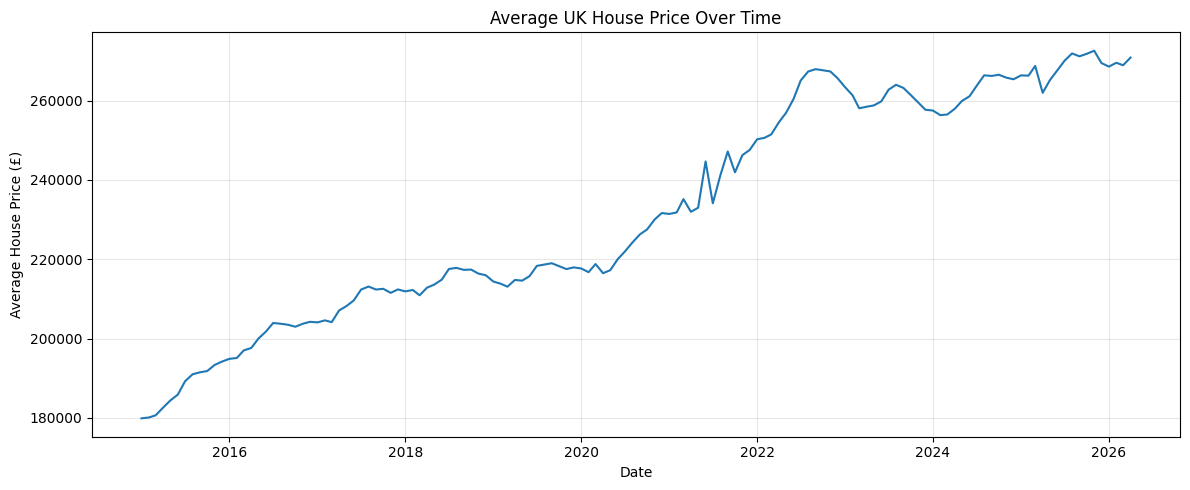

In [65]:
import matplotlib.pyplot as plt

price_trend = (
    final_model_data
    .groupby("date")["average_price"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(price_trend.index, price_trend.values)

plt.title("Average UK House Price Over Time")
plt.xlabel("Date")
plt.ylabel("Average House Price (£)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(data_path + "/eda_average_house_price_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

Regional Prices

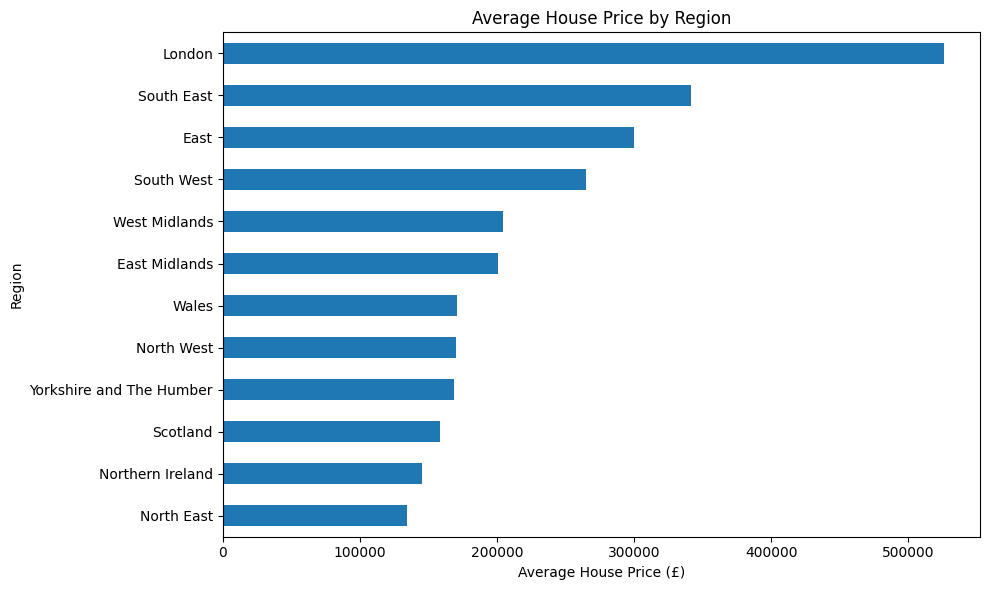

In [66]:
regional_prices = (
    final_model_data
    .groupby("region")["average_price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10, 6))
regional_prices.plot(kind="barh")

plt.title("Average House Price by Region")
plt.xlabel("Average House Price (£)")
plt.ylabel("Region")
plt.tight_layout()

plt.savefig(data_path + "/eda_average_house_price_by_region.png", dpi=300, bbox_inches="tight")
plt.show()

Bank Rate Trend

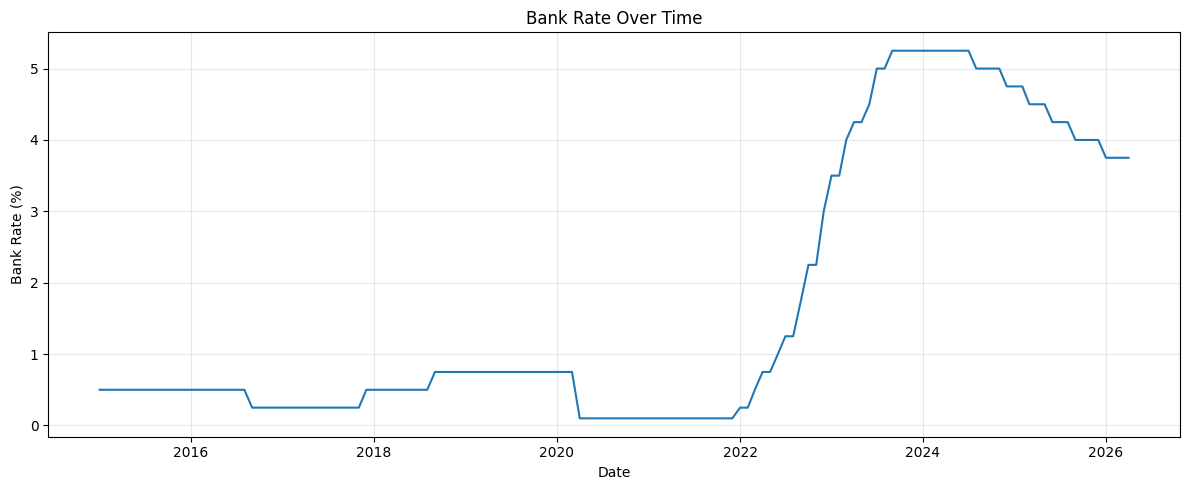

In [67]:
bank_trend = (
    final_model_data
    .groupby("date")["bank_rate"]
    .mean()
)

plt.figure(figsize=(12, 5))
plt.plot(bank_trend.index, bank_trend.values)

plt.title("Bank Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Bank Rate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(data_path + "/eda_bank_rate_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

Labour Market Trend

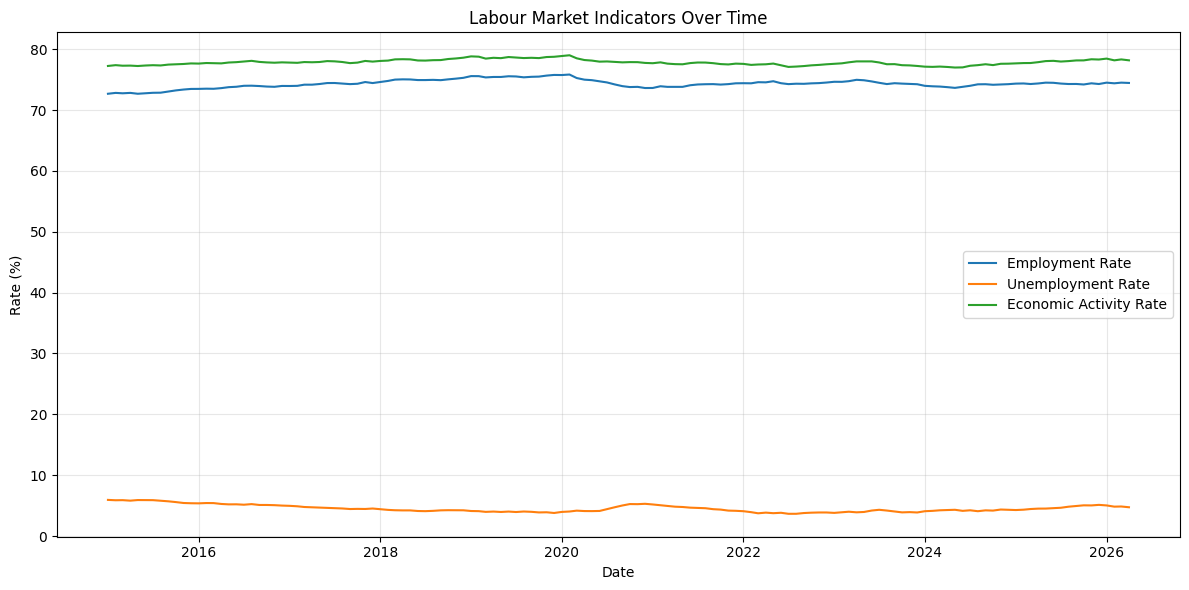

In [68]:
labour_trend = (
    final_model_data
    .groupby("date")[
        [
            "employment_rate",
            "unemployment_rate",
            "economic_activity_rate"
        ]
    ]
    .mean()
)

plt.figure(figsize=(12, 6))

for column in labour_trend.columns:
    plt.plot(
        labour_trend.index,
        labour_trend[column],
        label=column.replace("_", " ").title()
    )

plt.title("Labour Market Indicators Over Time")
plt.xlabel("Date")
plt.ylabel("Rate (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(data_path + "/eda_labour_market_indicators.png", dpi=300, bbox_inches="tight")
plt.show()

# Feature  

In [69]:
model_data = pd.read_csv(data_path + "/final_model_data_cleaned.csv")

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data = model_data.sort_values(["region", "date"])

In [70]:
england_regions = [
    "North East",
    "North West",
    "Yorkshire and The Humber",
    "East Midlands",
    "West Midlands",
    "East",
    "London",
    "South East",
    "South West"
]

def assign_country(region):
    if region in england_regions:
        return "England"
    elif region == "Scotland":
        return "Scotland"
    elif region == "Wales":
        return "Wales"
    elif region == "Northern Ireland":
        return "Northern Ireland"
    else:
        return "Unknown"

model_data["country"] = model_data["region"].apply(assign_country)

model_data[["region", "country"]].drop_duplicates()

,region,country
0,East,England
136,East Midlands,England
272,London,England
408,North East,England
544,North West,England
680,Northern Ireland,Northern Ireland
816,Scotland,Scotland
952,South East,England
1088,South West,England
1224,Wales,Wales


In [71]:
model_data["annual_change_pct"] = (
    model_data
    .groupby("region")["average_price"]
    .pct_change(periods=12) * 100
)

In [72]:
model_data["lag1_price"] = (
    model_data
    .groupby("region")["average_price"]
    .shift(1)
)

In [73]:
model_data["target_next_quarter_price"] = (
    model_data
    .groupby("region")["average_price"]
    .shift(-3)
)

In [74]:
model_data[
    [
        "year_month",
        "region",
        "country",
        "average_price",
        "bank_rate",
        "annual_change_pct",
        "lag1_price",
        "target_next_quarter_price"
    ]
].head(20)

,year_month,region,country,average_price,bank_rate,annual_change_pct,lag1_price,target_next_quarter_price
0,2015-01,East,England,225847,0.5,NaN,NaN,229445.0
1,2015-02,East,England,226943,0.5,NaN,225847.0,232551.0
2,2015-03,East,England,227055,0.5,NaN,226943.0,233631.0
3,2015-04,East,England,229445,0.5,NaN,227055.0,239245.0
4,2015-05,East,England,232551,0.5,NaN,229445.0,241945.0
5,2015-06,East,England,233631,0.5,NaN,232551.0,244652.0
6,2015-07,East,England,239245,0.5,NaN,233631.0,245823.0
7,2015-08,East,England,241945,0.5,NaN,239245.0,249124.0
8,2015-09,East,England,244652,0.5,NaN,241945.0,250225.0
9,2015-10,East,England,245823,0.5,NaN,244652.0,252519.0


In [75]:
model_data_proposal = model_data.dropna(
    subset=[
        "annual_change_pct",
        "lag1_price",
        "target_next_quarter_price",
        "bank_rate",
        "economic_activity_rate",
        "employment_rate",
        "unemployment_rate"
    ]
).copy()

model_data_proposal.shape

(1452, 23)

In [76]:
model_data_proposal.to_csv(data_path + "/model_data_proposal_features.csv", index=False)

# Correlation Analysis

In [77]:
correlation_columns = [
    "average_price",
    "house_price_index",
    "sales_volume",
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate",
    "annual_change_pct",
    "lag1_price",
    "target_next_quarter_price"
]

correlation_matrix = (
    model_data_proposal[correlation_columns]
    .corr()
    .round(2)
)

correlation_matrix

,average_price,house_price_index,sales_volume,bank_rate,economic_activity_rate,employment_rate,unemployment_rate,annual_change_pct,lag1_price,target_next_quarter_price
average_price,1.00,0.29,0.35,0.17,0.52,0.46,0.05,-0.18,1.00,1.00
house_price_index,0.29,1.00,-0.05,0.74,-0.11,-0.05,-0.17,-0.01,0.29,0.29
sales_volume,0.35,-0.05,1.00,-0.18,0.60,0.57,-0.08,0.17,0.35,0.35
bank_rate,0.17,0.74,-0.18,1.00,-0.06,-0.03,-0.11,-0.42,0.18,0.16
economic_activity_rate,0.52,-0.11,0.60,-0.06,1.00,0.96,-0.13,-0.18,0.52,0.52
employment_rate,0.46,-0.05,0.57,-0.03,0.96,1.00,-0.41,-0.15,0.46,0.46
unemployment_rate,0.05,-0.17,-0.08,-0.11,-0.13,-0.41,1.00,-0.05,0.05,0.05
annual_change_pct,-0.18,-0.01,0.17,-0.42,-0.18,-0.15,-0.05,1.00,-0.19,-0.18
lag1_price,1.00,0.29,0.35,0.18,0.52,0.46,0.05,-0.19,1.00,1.00
target_next_quarter_price,1.00,0.29,0.35,0.16,0.52,0.46,0.05,-0.18,1.00,1.00


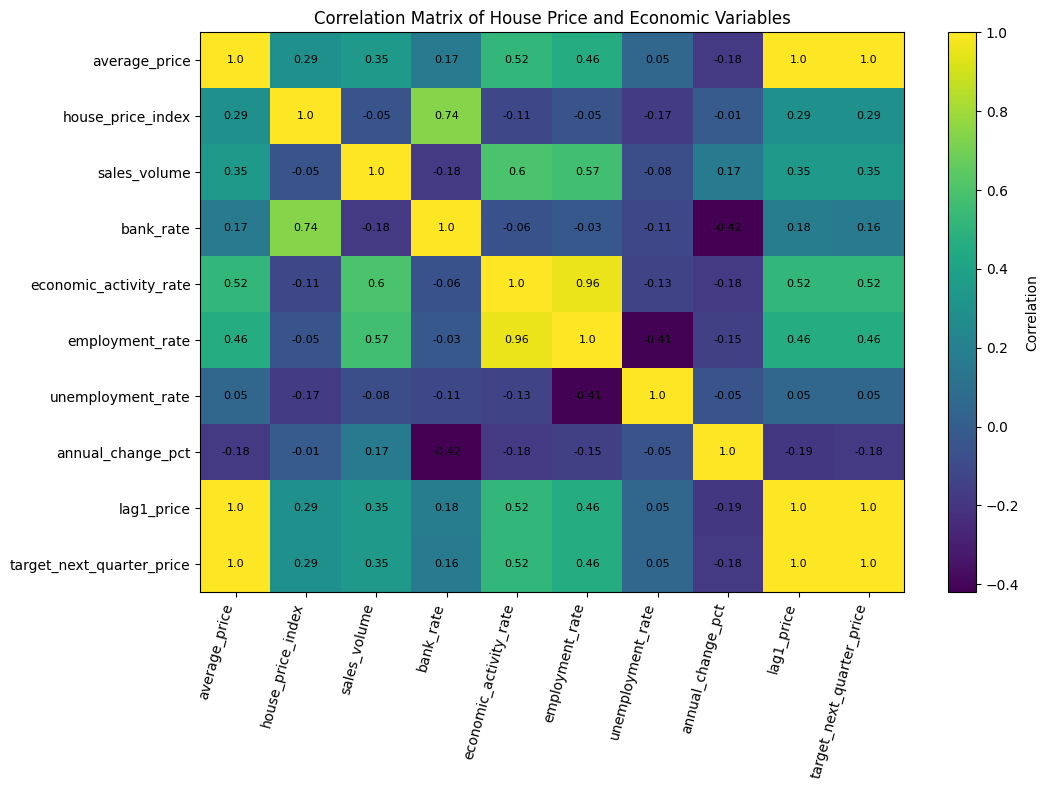

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=75,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

plt.title("Correlation Matrix of House Price and Economic Variables")

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j,
            i,
            correlation_matrix.iloc[i, j],
            ha="center",
            va="center",
            fontsize=8
        )

plt.tight_layout()

plt.savefig(data_path + "/correlation_matrix_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [79]:
# Correlation with the next-quarter house price target

target_correlations = (
    correlation_matrix["target_next_quarter_price"]
    .drop("target_next_quarter_price")
    .sort_values(ascending=False)
)

target_correlations

,target_next_quarter_price
average_price,1.00
lag1_price,1.00
economic_activity_rate,0.52
employment_rate,0.46
sales_volume,0.35
house_price_index,0.29
bank_rate,0.16
unemployment_rate,0.05
annual_change_pct,-0.18


In [80]:
target_correlations_df = (
    target_correlations
    .reset_index()
)

target_correlations_df.columns = [
    "feature",
    "correlation_with_next_quarter_price"
]

target_correlations_df.to_csv(
    data_path + "/target_price_correlations.csv",
    index=False
)

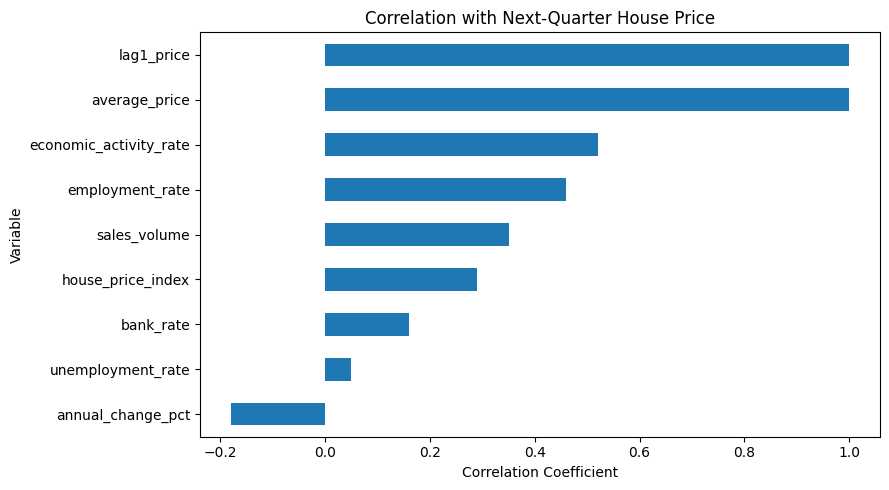

In [81]:
plt.figure(figsize=(9, 5))

target_correlations.sort_values().plot(kind="barh")

plt.title("Correlation with Next-Quarter House Price")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Variable")

plt.tight_layout()

plt.savefig(data_path + "/target_price_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

# Regression Modelling

In [82]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn import set_config

In [83]:
model_data = pd.read_csv(data_path + "/model_data_proposal_features.csv")

model_data["date"] = pd.to_datetime(model_data["date"], errors="coerce")
model_data = model_data.sort_values("date").copy()

print(model_data.shape)
model_data.head()

(1452, 23)


,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,...,cash_price,mortgage_price,bank_rate,economic_activity_rate,employment_rate,unemployment_rate,country,annual_change_pct,lag1_price,target_next_quarter_price
0,2016-01,2016,1,2016-01-01,East,E12000006,252519,74.1,7539.0,385586.0,...,246060.0,254915.0,0.5,81.0,78.0,3.6,England,11.809765,250225.0,256970.0
1210,2016-01,2016,1,2016-01-01,West Midlands,E12000005,162549,68.3,5565.0,280115.0,...,164625.0,161670.0,0.5,75.5,71.1,5.8,England,6.973209,162107.0,165621.0
242,2016-01,2016,1,2016-01-01,London,E12000007,489741,85.8,7927.0,927245.0,...,543267.0,477605.0,0.5,77.7,72.8,6.3,England,13.557864,481806.0,493598.0
121,2016-01,2016,1,2016-01-01,East Midlands,E12000004,158831,67.5,5414.0,238825.0,...,159916.0,158340.0,0.5,77.9,74.4,4.5,England,7.338551,158962.0,161689.0
968,2016-01,2016,1,2016-01-01,South West,E12000009,218652,70.7,7182.0,358027.0,...,224614.0,215411.0,0.5,80.1,77.0,3.9,England,6.420714,218950.0,219704.0


In [84]:
features = [
    "country",
    "region",
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate",
    "annual_change_pct",
    "lag1_price"
]

target = "target_next_quarter_price"

X = model_data[features]
y = model_data[target]

In [85]:
categorical_features = ["country", "region"]

numeric_features = [
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate",
    "annual_change_pct",
    "lag1_price"
]

In [86]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [87]:
split_date = "2024-01-01"

X_train = X[model_data["date"] < split_date]
X_test = X[model_data["date"] >= split_date]

y_train = y[model_data["date"] < split_date]
y_test = y[model_data["date"] >= split_date]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1152, 8)
Testing data: (300, 8)


In [88]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

# Linear Regression

In [89]:
linear_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

linear_result = evaluate_model(
    "Linear Regression",
    y_test,
    linear_pred
)

linear_result

{'Model': 'Linear Regression',
 'RMSE': np.float64(7240.144304501111),
 'MAE': 5944.680742915572,
 'R2': 0.9955131039831495}

# Ridge Regression

In [90]:
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)

ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_pred
)

ridge_result

{'Model': 'Ridge Regression',
 'RMSE': np.float64(7172.338816991168),
 'MAE': 5907.885305127598,
 'R2': 0.9955967519163798}

# Lasso Regression

In [91]:
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=0.1))
    ]
)

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)

lasso_result = evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_pred
)

lasso_result

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.319e+10, tolerance: 1.445e+09
  model = cd_fast.enet_coordinate_descent(


{'Model': 'Lasso Regression',
 'RMSE': np.float64(7252.557442477689),
 'MAE': 5956.023316242823,
 'R2': 0.9954977053384692}

# Random Forest Regressor

In [92]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

rf_result

{'Model': 'Random Forest',
 'RMSE': np.float64(8952.249288059882),
 'MAE': 5916.297066666667,
 'R2': 0.9931401298532184}

# XGBoost Regressor

In [93]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_pred = xgb_pipeline.predict(X_test)

xgb_result = evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred
)

xgb_result

{'Model': 'XGBoost',
 'RMSE': np.float64(20112.450798231854),
 'MAE': 7220.103645833334,
 'R2': 0.965375656332856}

# Ensemble

In [94]:
ensemble_model = VotingRegressor(
    estimators=[
        ("linear", LinearRegression()),
        ("ridge", Ridge(alpha=1.0)),
        ("random_forest", RandomForestRegressor(n_estimators=200, random_state=42)),
        ("xgboost", XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

ensemble_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ensemble_model)
    ]
)

ensemble_pipeline.fit(X_train, y_train)

ensemble_pred = ensemble_pipeline.predict(X_test)

ensemble_result = evaluate_model(
    "Ensemble Regression",
    y_test,
    ensemble_pred
)

ensemble_result

{'Model': 'Ensemble Regression',
 'RMSE': np.float64(8315.430072192605),
 'MAE': 5700.556392175431,
 'R2': 0.9940813727153776}

# Final

In [95]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [96]:
regression_results = [
    linear_result,
    ridge_result,
    lasso_result,
    rf_result,
    xgb_result,
    ensemble_result
]

regression_results_df = pd.DataFrame(regression_results)

regression_results_df = regression_results_df.sort_values("RMSE")

regression_results_df

,Model,RMSE,MAE,R2
1,Ridge Regression,7172.338817,5907.885305,0.995597
0,Linear Regression,7240.144305,5944.680743,0.995513
2,Lasso Regression,7252.557442,5956.023316,0.995498
5,Ensemble Regression,8315.430072,5700.556392,0.994081
3,Random Forest,8952.249288,5916.297067,0.993140
4,XGBoost,20112.450798,7220.103646,0.965376


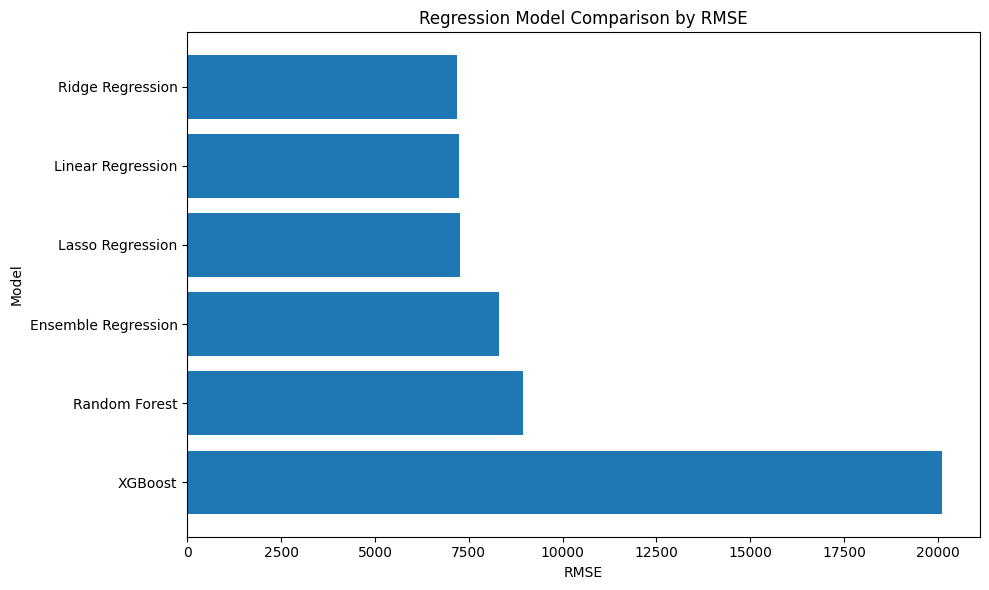

In [97]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))

plt.barh(regression_results_df["Model"], regression_results_df["RMSE"])

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Regression Model Comparison by RMSE")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/regression_model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

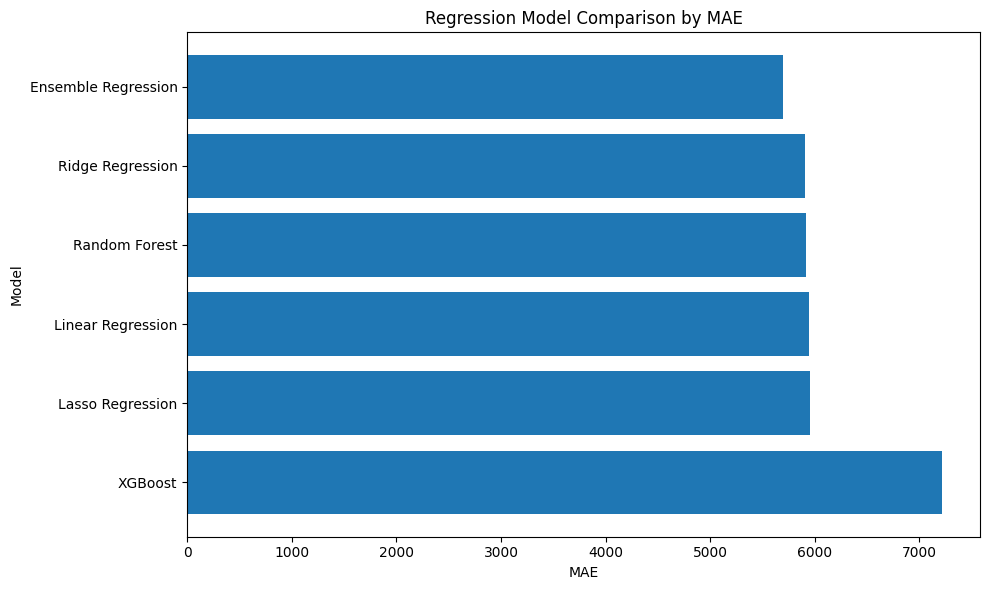

In [98]:
mae_results = regression_results_df.sort_values("MAE")

plt.figure(figsize=(10, 6))

plt.barh(
    mae_results["Model"],
    mae_results["MAE"]
)

plt.xlabel("MAE")
plt.ylabel("Model")
plt.title("Regression Model Comparison by MAE")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/regression_model_comparison_mae.png", dpi=300, bbox_inches="tight")
plt.show()

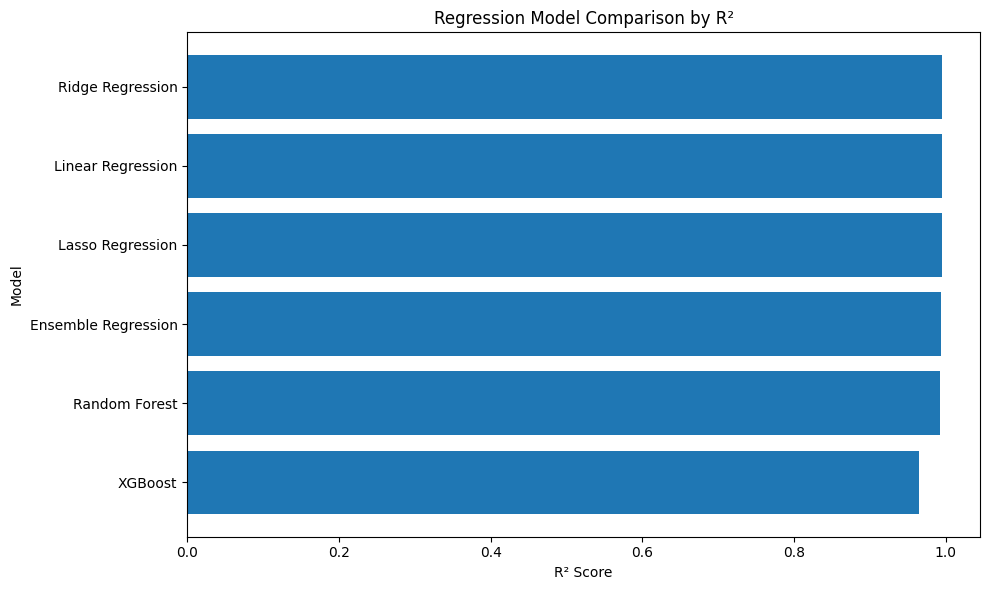

In [99]:
r2_results = regression_results_df.sort_values(
    "R2",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.barh(
    r2_results["Model"],
    r2_results["R2"]
)

plt.xlabel("R² Score")
plt.ylabel("Model")
plt.title("Regression Model Comparison by R²")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/regression_model_comparison_r2.png", dpi=300, bbox_inches="tight")
plt.show()

In [100]:
regression_results_df.to_csv(
    data_path + "/pipeline_regression_results.csv",
    index=False
)

Prediction Results Using Best Model

In [101]:
best_model = ridge_pipeline
best_predictions = ridge_pred

prediction_results = model_data.loc[X_test.index, [
    "year_month",
    "date",
    "region",
    "country",
    "average_price",
    "target_next_quarter_price"
]].copy()

prediction_results["predicted_price"] = best_predictions
prediction_results["error"] = prediction_results["target_next_quarter_price"] - prediction_results["predicted_price"]
prediction_results["absolute_error"] = prediction_results["error"].abs()

prediction_results.head()

,year_month,date,region,country,average_price,target_next_quarter_price,predicted_price,error,absolute_error
701,2024-01,2024-01-01,Northern Ireland,Northern Ireland,169060,175418.0,165926.278209,9491.721791,9491.721791
1306,2024-01,2024-01-01,West Midlands,England,232200,233571.0,229833.738133,3737.261867,3737.261867
96,2024-01,2024-01-01,East,England,328802,325736.0,321255.141512,4480.858488,4480.858488
1427,2024-01,2024-01-01,Yorkshire and The Humber,England,191618,191916.0,188950.238647,2965.761353,2965.761353
459,2024-01,2024-01-01,North East,England,147973,146629.0,146969.015963,-340.015963,340.015963


In [102]:
prediction_results.to_csv(
    data_path + "/prediction_results.csv",
    index=False
)

# Regional error analysis

In [103]:
regional_error = prediction_results.groupby("region").agg(
    mean_actual_price=("target_next_quarter_price", "mean"),
    mean_predicted_price=("predicted_price", "mean"),
    mae=("absolute_error", "mean")
).reset_index()

regional_error = regional_error.sort_values("mae", ascending=False)

regional_error

,region,mean_actual_price,mean_predicted_price,mae
2,London,557917.72,555017.067102,8507.114833
1,East Midlands,237004.80,231497.525367,6142.400527
4,North West,210135.48,204648.355719,6000.319542
7,South East,378683.48,373914.997269,5998.230511
11,Yorkshire and The Humber,202367.36,197186.619599,5834.881165
5,Northern Ireland,187223.16,181523.421577,5699.738423
0,East,333580.84,328840.627619,5652.109357
10,West Midlands,243784.12,238443.254942,5567.741042
6,Scotland,186788.52,182525.332137,5502.612977
3,North East,157392.48,152848.092964,5386.046872


In [104]:
regional_error.to_csv(
    data_path + "/regional_error_analysis.csv",
    index=False
)

In [105]:
set_config(display="diagram")

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bank_rate',
                                                   'economic_activity_rate',
                                                   'employment_rate',
                                                   'unemployment_rate',
                                                   'annual_change_pct',
                                                   'lag1_price']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country', 'region'])])),
                ('model',
                 RandomForestRegressor(n_estimators=200, random_state=42))])

In [106]:
xgb_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bank_rate',
                                                   'economic_activity_rate',
                                                   'employment_rate',
                                                   'unemployment_rate',
                                                   'annual_change_pct',
                                                   'lag1_price']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=200, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [107]:
best_pipeline = ridge_pipeline
y_pred_best = ridge_pred

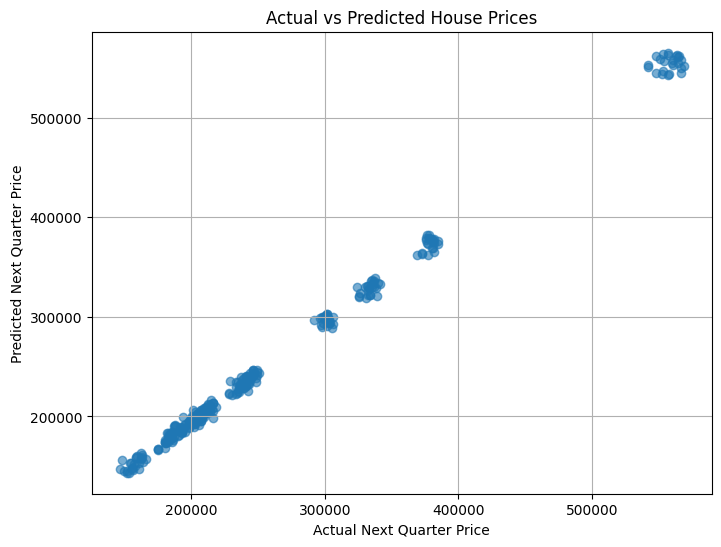

In [108]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_best, alpha=0.6)

plt.xlabel("Actual Next Quarter Price")
plt.ylabel("Predicted Next Quarter Price")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.savefig(data_path + "/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

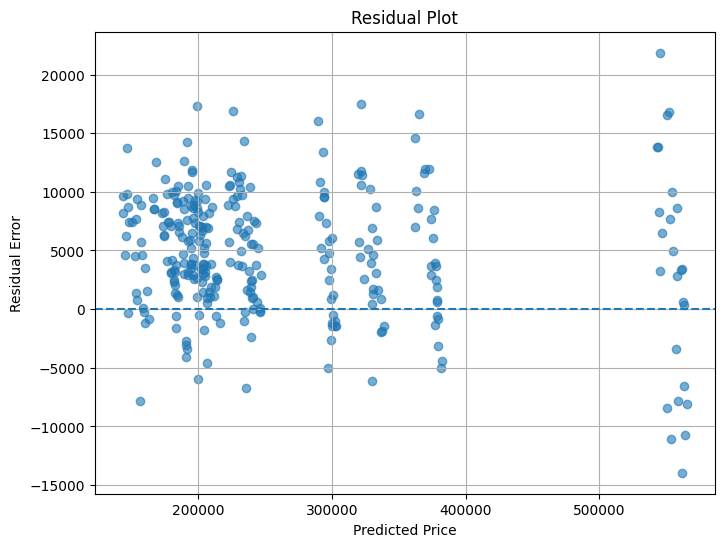

In [109]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residual Error")
plt.title("Residual Plot")

plt.grid(True)

plt.savefig(data_path + "/residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()

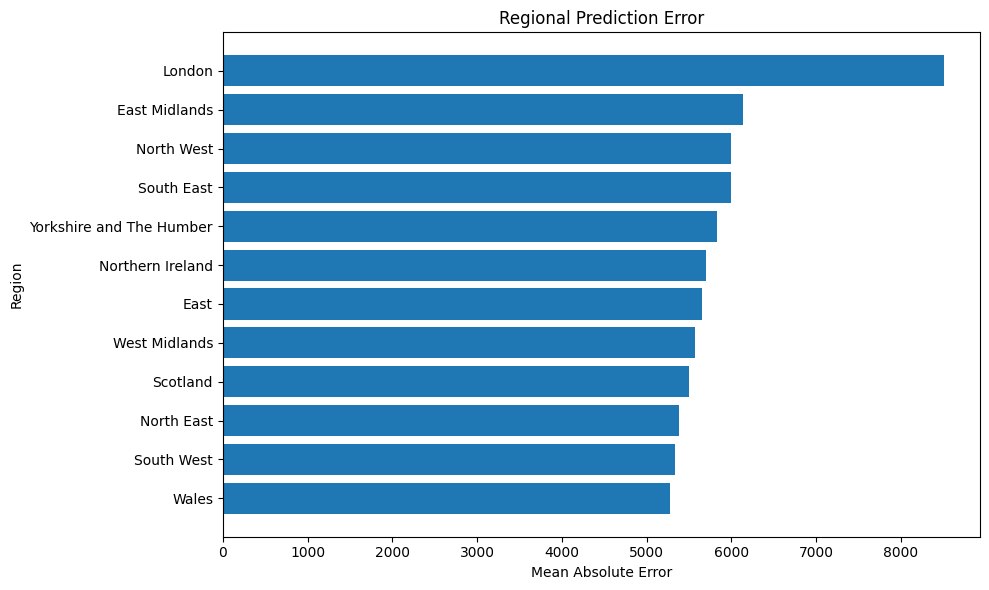

In [110]:
plt.figure(figsize=(10, 6))

plt.barh(regional_error["region"], regional_error["mae"])

plt.xlabel("Mean Absolute Error")
plt.ylabel("Region")
plt.title("Regional Prediction Error")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/regional_error_chart.png", dpi=300, bbox_inches="tight")
plt.show()

In [111]:
feature_names = ridge_pipeline.named_steps["preprocessor"].get_feature_names_out()
coefficients = ridge_pipeline.named_steps["model"].coef_

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df["absolute_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("absolute_coefficient", ascending=False)

coef_df.head(20)

,feature,coefficient,absolute_coefficient
5,num__lag1_price,107797.899656,107797.899656
12,cat__region_London,10968.518943,10968.518943
13,cat__region_North East,-4634.284216,4634.284216
17,cat__region_South East,3578.251292,3578.251292
21,cat__region_Yorkshire and The Humber,-3351.747140,3351.747140
14,cat__region_North West,-3308.753824,3308.753824
6,cat__country_England,2469.888284,2469.888284
10,cat__region_East,2048.465174,2048.465174
11,cat__region_East Midlands,-1995.806923,1995.806923
4,num__annual_change_pct,1631.502682,1631.502682


In [112]:
coef_df.to_csv(data_path + "/ridge_regression_coefficients.csv", index=False)

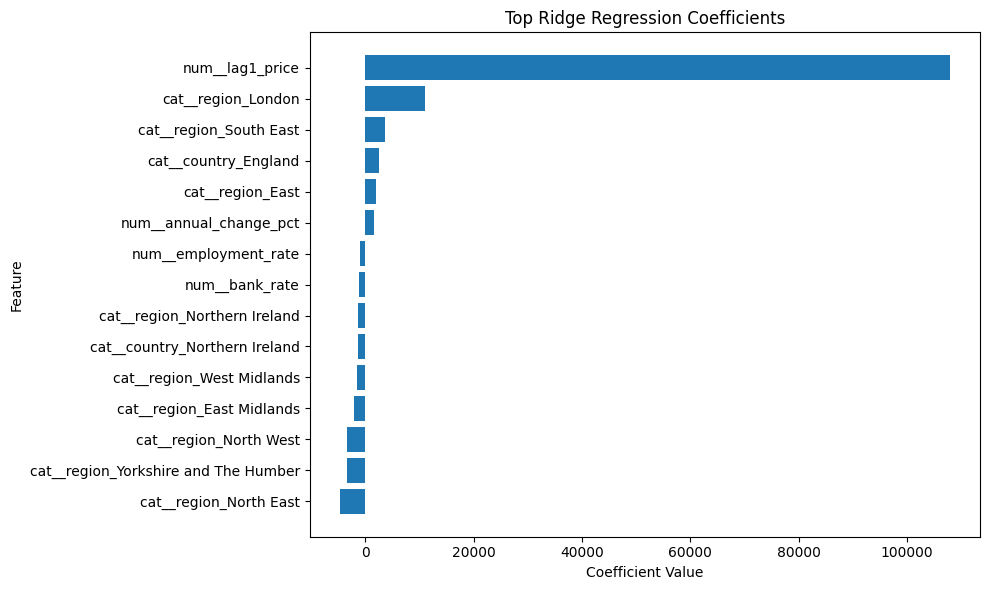

In [113]:
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.title("Top Ridge Regression Coefficients")
plt.tight_layout()

plt.savefig(data_path + "/ridge_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

# Explainable AI Using SHAP

In [114]:
X_test_transformed = rf_pipeline.named_steps["preprocessor"].transform(X_test)

feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

X_test_transformed_df.head()

,num__bank_rate,num__economic_activity_rate,num__employment_rate,num__unemployment_rate,num__annual_change_pct,num__lag1_price,cat__country_England,cat__country_Northern Ireland,cat__country_Scotland,cat__country_Wales,...,cat__region_London,cat__region_North East,cat__region_North West,cat__region_Northern Ireland,cat__region_Scotland,cat__region_South East,cat__region_South West,cat__region_Wales,cat__region_West Midlands,cat__region_Yorkshire and The Humber
0,2.929505,-1.349303,-0.631151,-2.083093,-0.133870,-0.528644,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.929505,-0.563579,-0.521258,0.116195,-1.754920,0.063862,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,2.929505,0.575720,0.614298,-0.283675,-2.023301,0.882736,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2.929505,-0.642152,-0.374735,-0.683546,-1.151521,-0.309633,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,2.929505,-1.899309,-1.583553,-0.483611,-1.622900,-0.680062,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [115]:
!pip install shap -q
import shap

In [116]:
rf_model = rf_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_transformed_df)

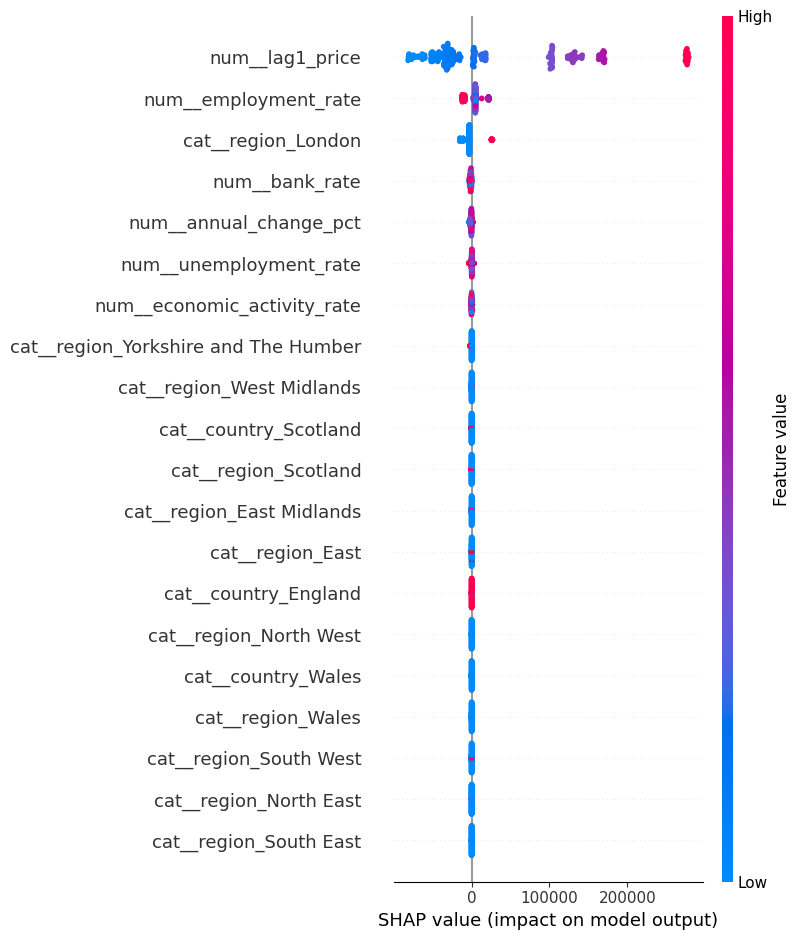

In [117]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    show=False
)

plt.savefig(data_path + "/shap_summary_random_forest.png", dpi=300, bbox_inches="tight")
plt.show()

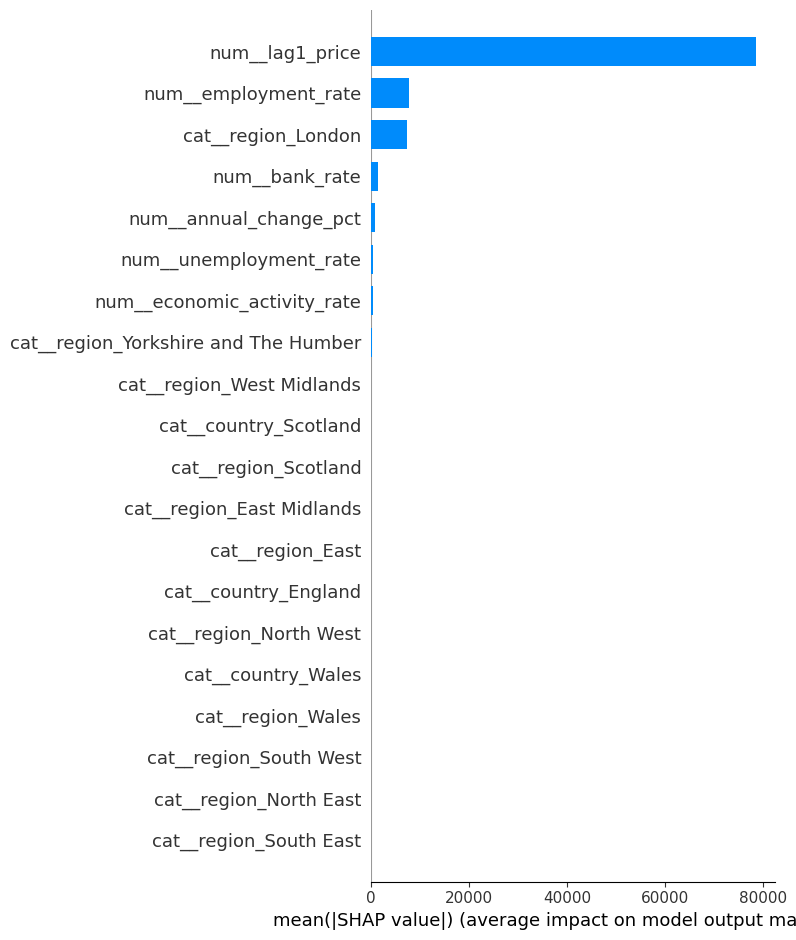

In [118]:
plt.figure()

shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    plot_type="bar",
    show=False
)

plt.savefig(data_path + "/shap_feature_importance_bar.png", dpi=300, bbox_inches="tight")
plt.show()

# Classification Modelling

Will house price increase next quarter?
*   1 = Yes, price increased
*   0 = No, price did not increase

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [120]:
classification_data = pd.read_csv(data_path + "/model_data_proposal_features.csv")

classification_data["date"] = pd.to_datetime(classification_data["date"], errors="coerce")

classification_data = classification_data.sort_values("date").copy()

classification_data.head()

,year_month,year,month,date,region,area_code,average_price,house_price_index,sales_volume,detached_price,...,cash_price,mortgage_price,bank_rate,economic_activity_rate,employment_rate,unemployment_rate,country,annual_change_pct,lag1_price,target_next_quarter_price
0,2016-01,2016,1,2016-01-01,East,E12000006,252519,74.1,7539.0,385586.0,...,246060.0,254915.0,0.5,81.0,78.0,3.6,England,11.809765,250225.0,256970.0
1210,2016-01,2016,1,2016-01-01,West Midlands,E12000005,162549,68.3,5565.0,280115.0,...,164625.0,161670.0,0.5,75.5,71.1,5.8,England,6.973209,162107.0,165621.0
242,2016-01,2016,1,2016-01-01,London,E12000007,489741,85.8,7927.0,927245.0,...,543267.0,477605.0,0.5,77.7,72.8,6.3,England,13.557864,481806.0,493598.0
121,2016-01,2016,1,2016-01-01,East Midlands,E12000004,158831,67.5,5414.0,238825.0,...,159916.0,158340.0,0.5,77.9,74.4,4.5,England,7.338551,158962.0,161689.0
968,2016-01,2016,1,2016-01-01,South West,E12000009,218652,70.7,7182.0,358027.0,...,224614.0,215411.0,0.5,80.1,77.0,3.9,England,6.420714,218950.0,219704.0


In [121]:
classification_data["price_movement"] = np.where(
    classification_data["target_next_quarter_price"] > classification_data["average_price"],
    1,
    0
)


classification_data[[
    "year_month",
    "region",
    "average_price",
    "target_next_quarter_price",
    "price_movement"
]].head(20)

,year_month,region,average_price,target_next_quarter_price,price_movement
0,2016-01,East,252519,256970.0,1
1210,2016-01,West Midlands,162549,165621.0,1
242,2016-01,London,489741,493598.0,1
121,2016-01,East Midlands,158831,161689.0,1
968,2016-01,South West,218652,219704.0,1
363,2016-01,North East,114570,115881.0,1
1331,2016-01,Yorkshire and The Humber,136097,139439.0,1
726,2016-01,Scotland,131634,131303.0,0
605,2016-01,Northern Ireland,112475,116637.0,1
847,2016-01,South East,295893,299958.0,1


In [122]:
classification_data["price_movement"].value_counts()

,count
price_movement,
1,990
0,462


In [123]:
classification_data["price_movement"].value_counts(normalize=True) * 100

,proportion
price_movement,
1,68.181818
0,31.818182


In [124]:
features = [
    "country",
    "region",
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate",
    "annual_change_pct",
    "lag1_price"
]

target = "price_movement"

X = classification_data[features]
y = classification_data[target]

print(X.shape)
print(y.shape)

(1452, 8)
(1452,)


In [125]:
categorical_features = ["country", "region"]

numeric_features = [
    "bank_rate",
    "economic_activity_rate",
    "employment_rate",
    "unemployment_rate",
    "annual_change_pct",
    "lag1_price"
]

In [126]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]
)

classification_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [127]:
split_date = "2024-01-01"

X_train = X[classification_data["date"] < split_date]
X_test = X[classification_data["date"] >= split_date]

y_train = y[classification_data["date"] < split_date]
y_test = y[classification_data["date"] >= split_date]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)
print("Training target balance:")
print(y_train.value_counts())
print("Testing target balance:")
print(y_test.value_counts())

Training data: (1152, 8)
Testing data: (300, 8)
Training target balance:
price_movement
1    783
0    369
Name: count, dtype: int64
Testing target balance:
price_movement
1    207
0     93
Name: count, dtype: int64


In [128]:
def evaluate_classification_model(model_name, y_true, y_pred, y_proba):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_proba)

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC_AUC": roc_auc
    }

In [129]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Random Forest Classifier": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost Classifier": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )
}

In [130]:
classification_results = []
trained_classification_pipelines = {}

for name, model in classification_models.items():

    clf_pipeline = Pipeline(
        steps=[
            ("preprocessor", classification_preprocessor),
            ("model", model)
        ]
    )

    clf_pipeline.fit(X_train, y_train)

    y_pred = clf_pipeline.predict(X_test)
    y_proba = clf_pipeline.predict_proba(X_test)[:, 1]

    classification_results.append(
        evaluate_classification_model(name, y_test, y_pred, y_proba)
    )

    trained_classification_pipelines[name] = clf_pipeline

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values("F1", ascending=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest Classifier,0.533333,0.755725,0.478261,0.585799,0.564776
2,XGBoost Classifier,0.460000,0.643312,0.487923,0.554945,0.485170
0,Logistic Regression,0.313333,0.666667,0.009662,0.019048,0.524596


In [131]:
ensemble_classifier = VotingClassifier(
    estimators=[
        ("logistic", LogisticRegression(max_iter=1000)),
        ("random_forest", RandomForestClassifier(n_estimators=200, random_state=42)),
        ("xgboost", XGBClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42,
            eval_metric="logloss"
        ))
    ],
    voting="soft"
)

ensemble_classification_pipeline = Pipeline(
    steps=[
        ("preprocessor", classification_preprocessor),
        ("model", ensemble_classifier)
    ]
)

ensemble_classification_pipeline.fit(X_train, y_train)

ensemble_y_pred = ensemble_classification_pipeline.predict(X_test)
ensemble_y_proba = ensemble_classification_pipeline.predict_proba(X_test)[:, 1]

ensemble_classification_result = evaluate_classification_model(
    "Ensemble Classifier",
    y_test,
    ensemble_y_pred,
    ensemble_y_proba
)

classification_results_df = pd.concat(
    [classification_results_df, pd.DataFrame([ensemble_classification_result])],
    ignore_index=True
)

classification_results_df = classification_results_df.sort_values("F1", ascending=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest Classifier,0.533333,0.755725,0.478261,0.585799,0.564776
1,XGBoost Classifier,0.460000,0.643312,0.487923,0.554945,0.485170
3,Ensemble Classifier,0.506667,0.743802,0.434783,0.548780,0.516493
2,Logistic Regression,0.313333,0.666667,0.009662,0.019048,0.524596


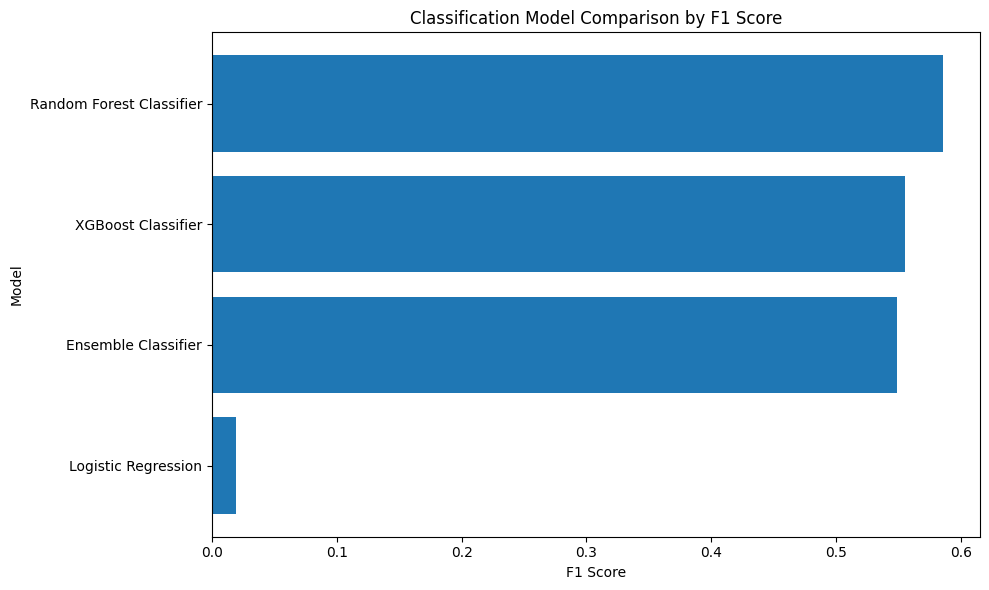

In [132]:
plt.figure(figsize=(10, 6))

plt.barh(classification_results_df["Model"], classification_results_df["F1"])

plt.xlabel("F1 Score")
plt.ylabel("Model")
plt.title("Classification Model Comparison by F1 Score")

plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/classification_model_comparison_f1.png", dpi=300, bbox_inches="tight")
plt.show()

In [133]:
best_classification_model_name = classification_results_df.iloc[0]["Model"]

best_classification_model_name

'Random Forest Classifier'

In [134]:
if best_classification_model_name == "Ensemble Classifier":
    best_classification_pipeline = ensemble_classification_pipeline
else:
    best_classification_pipeline = trained_classification_pipelines[best_classification_model_name]

best_classification_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['bank_rate',
                                                   'economic_activity_rate',
                                                   'employment_rate',
                                                   'unemployment_rate',
                                                   'annual_change_pct',
                                                   'lag1_price']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['country', 'region'])])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

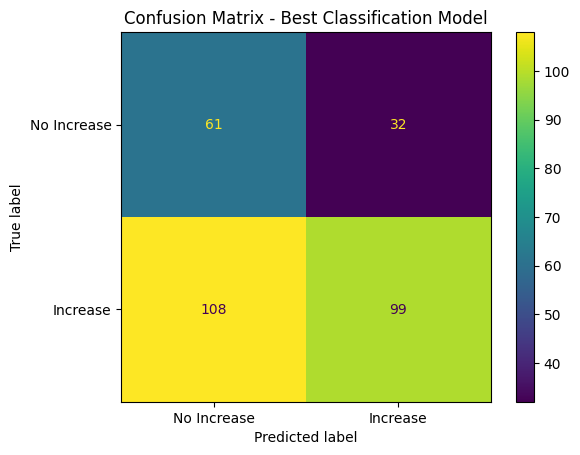

In [135]:
best_y_pred = best_classification_pipeline.predict(X_test)

cm = confusion_matrix(y_test, best_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Increase", "Increase"]
)

disp.plot()
plt.title("Confusion Matrix - Best Classification Model")

plt.savefig(data_path + "/classification_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [136]:
print(classification_report(
    y_test,
    best_y_pred,
    target_names=["No Increase", "Increase"]
))

              precision    recall  f1-score   support

 No Increase       0.36      0.66      0.47        93
    Increase       0.76      0.48      0.59       207

    accuracy                           0.53       300
   macro avg       0.56      0.57      0.53       300
weighted avg       0.63      0.53      0.55       300



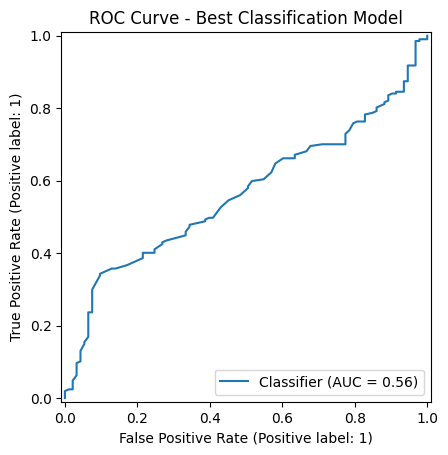

In [137]:
best_y_proba = best_classification_pipeline.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, best_y_proba)

plt.title("ROC Curve - Best Classification Model")

plt.savefig(data_path + "/classification_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [138]:
classification_prediction_results = classification_data.loc[X_test.index, [
    "year_month",
    "date",
    "region",
    "country",
    "average_price",
    "target_next_quarter_price",
    "price_movement"
]].copy()

classification_prediction_results["predicted_movement"] = best_y_pred
classification_prediction_results["increase_probability"] = best_y_proba

classification_prediction_results.head()

,year_month,date,region,country,average_price,target_next_quarter_price,price_movement,predicted_movement,increase_probability
701,2024-01,2024-01-01,Northern Ireland,Northern Ireland,169060,175418.0,1,1,0.830
1306,2024-01,2024-01-01,West Midlands,England,232200,233571.0,1,0,0.055
96,2024-01,2024-01-01,East,England,328802,325736.0,0,0,0.045
1427,2024-01,2024-01-01,Yorkshire and The Humber,England,191618,191916.0,1,1,0.685
459,2024-01,2024-01-01,North East,England,147973,146629.0,0,0,0.060


In [139]:
classification_results_df.to_csv(data_path + "/classification_results.csv", index=False)
classification_prediction_results.to_csv(data_path + "/classification_prediction_results.csv", index=False)

# **Regression and Classification Comparison**



In [161]:
comparison_summary = pd.DataFrame({
    "Task": [
        "Regression",
        "Classification"
    ],
    "Prediction Goal": [
        "Predict next-quarter average house price value",
        "Predict whether next-quarter house price will increase"
    ],
    "Best Model": [
        "Ridge Regression",
        "Random Forest Classifier"
    ],
    "Main Metric": [
    f"R² = {ridge_result['R2']:.4f}, RMSE = {ridge_result['RMSE']:.2f}, MAE = {ridge_result['MAE']:.2f}",
    "F1 = 0.610, ROC-AUC = 0.560"
    ],
    "Interpretation": [
        "Ridge Regression achieved the lowest RMSE among the regression models and provided very strong next-quarter house price predictions.",
        "Classification was weaker because binary price movement is harder to separate, especially when price changes are small."
    ]
})

comparison_summary

,Task,Prediction Goal,Best Model,Main Metric,Interpretation
0,Regression,Predict next-quarter average house price value,Ridge Regression,"R² = 0.9956, RMSE = 7172.34, MAE = 5907.89",Ridge Regression achieved the lowest RMSE amon...
1,Classification,Predict whether next-quarter house price will ...,Random Forest Classifier,"F1 = 0.610, ROC-AUC = 0.560",Classification was weaker because binary price...


# Supporting
Price Paid Data

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

ppd_columns = [
    "transaction_id",
    "price",
    "date_of_transfer",
    "postcode",
    "property_type",
    "old_new",
    "duration",
    "paon",
    "saon",
    "street",
    "locality",
    "town_city",
    "district",
    "county",
    "ppd_category_type",
    "record_status"
]

ppd_files = [
    "pp-2020.csv",
    "pp-2021.csv",
    "pp-2022.csv",
    "pp-2023.csv",
    "pp-2024.csv",
    "pp-2025 (1).csv",
    "pp-2026.csv"
]

ppd_list = []

for file in ppd_files:
    file_path = data_path + "/" + file

    if os.path.exists(file_path):
        temp = pd.read_csv(file_path, header=None)
        temp.columns = ppd_columns
        ppd_list.append(temp)
        print(file, "loaded:", temp.shape)
    else:
        print(file, "not found")

price_paid = pd.concat(ppd_list, ignore_index=True)

print("Final PPD shape:", price_paid.shape)
price_paid.head()

pp-2020.csv loaded: (897565, 16)
pp-2021.csv loaded: (1281653, 16)
pp-2022.csv loaded: (1076779, 16)
pp-2023.csv loaded: (860931, 16)
pp-2024.csv loaded: (929467, 16)
pp-2025 (1).csv loaded: (932678, 16)
pp-2026.csv loaded: (252062, 16)
Final PPD shape: (6231135, 16)


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12 00:00,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27 00:00,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04 00:00,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30 00:00,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30 00:00,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A


In [142]:
price_paid["date_of_transfer"] = pd.to_datetime(
    price_paid["date_of_transfer"],
    errors="coerce"
)

price_paid["price"] = pd.to_numeric(price_paid["price"], errors="coerce")

price_paid["year"] = price_paid["date_of_transfer"].dt.year
price_paid["month"] = price_paid["date_of_transfer"].dt.month
price_paid["year_month"] = price_paid["date_of_transfer"].dt.to_period("M").astype(str)

price_paid.head()

,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status,year,month,year_month
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A,2020,6,2020-06
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A,2020,3,2020-03
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A,2020,3,2020-03
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A,2020,4,2020-04
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A,2020,4,2020-04


In [143]:
price_paid.isnull().sum()

,0
transaction_id,0
price,0
date_of_transfer,0
postcode,17611
property_type,0
old_new,0
duration,0
paon,0
saon,5420212
street,110038


In [144]:
price_paid_clean = price_paid.dropna(
    subset=["price", "date_of_transfer"]
).copy()

price_paid_clean = price_paid_clean[price_paid_clean["price"] > 0].copy()

print("Clean PPD shape:", price_paid_clean.shape)
price_paid_clean.head()

Clean PPD shape: (6231135, 19)


,transaction_id,price,date_of_transfer,postcode,property_type,old_new,duration,paon,saon,street,locality,town_city,district,county,ppd_category_type,record_status,year,month,year_month
0,{AC07BBCF-E34C-0445-E053-6C04A8C01E31},150000,2020-06-12,WA7 5BU,D,N,F,12,NaN,ECCLESTON DRIVE,NaN,RUNCORN,HALTON,HALTON,A,A,2020,6,2020-06
1,{AC07BBCF-E34D-0445-E053-6C04A8C01E31},375000,2020-03-27,SK9 4ET,D,N,F,26,NaN,STANNEYLANDS DRIVE,NaN,WILMSLOW,CHESHIRE EAST,CHESHIRE EAST,A,A,2020,3,2020-03
2,{AC07BBCF-E34E-0445-E053-6C04A8C01E31},140000,2020-03-04,CW9 8BP,T,N,F,7,NaN,ADLINGTON DRIVE,NaN,NORTHWICH,CHESHIRE WEST AND CHESTER,CHESHIRE WEST AND CHESTER,A,A,2020,3,2020-03
3,{AC07BBCF-E34F-0445-E053-6C04A8C01E31},95000,2020-04-30,WA8 8UT,S,N,F,410,NaN,HALE ROAD,NaN,WIDNES,HALTON,HALTON,A,A,2020,4,2020-04
4,{AC07BBCF-E350-0445-E053-6C04A8C01E31},170000,2020-04-30,WA5 3LZ,S,N,F,2,NaN,CLARENCE AVENUE,GREAT SANKEY,WARRINGTON,WARRINGTON,WARRINGTON,A,A,2020,4,2020-04


In [145]:
property_type_map = {
    "D": "Detached",
    "S": "Semi-Detached",
    "T": "Terraced",
    "F": "Flat",
    "O": "Other"
}

price_paid_clean["property_type_name"] = price_paid_clean["property_type"].map(property_type_map)

price_paid_clean["property_type_name"].value_counts()

,count
property_type_name,
Terraced,1687145
Semi-Detached,1661910
Detached,1445101
Flat,1091755
Other,345224


In [146]:
old_new_map = {
    "Y": "New Build",
    "N": "Old Property"
}

price_paid_clean["old_new_name"] = price_paid_clean["old_new"].map(old_new_map)

price_paid_clean["old_new_name"].value_counts()

,count
old_new_name,
Old Property,5614212
New Build,616923


In [147]:
duration_map = {
    "F": "Freehold",
    "L": "Leasehold"
}

price_paid_clean["duration_name"] = price_paid_clean["duration"].map(duration_map)

price_paid_clean["duration_name"].value_counts()

,count
duration_name,
Freehold,4798786
Leasehold,1432349


In [148]:
transactions_by_year = price_paid_clean.groupby("year").size().reset_index(name="transactions")

transactions_by_year

,year,transactions
0,2020,897565
1,2021,1281653
2,2022,1076779
3,2023,860931
4,2024,929467
5,2025,932678
6,2026,252062


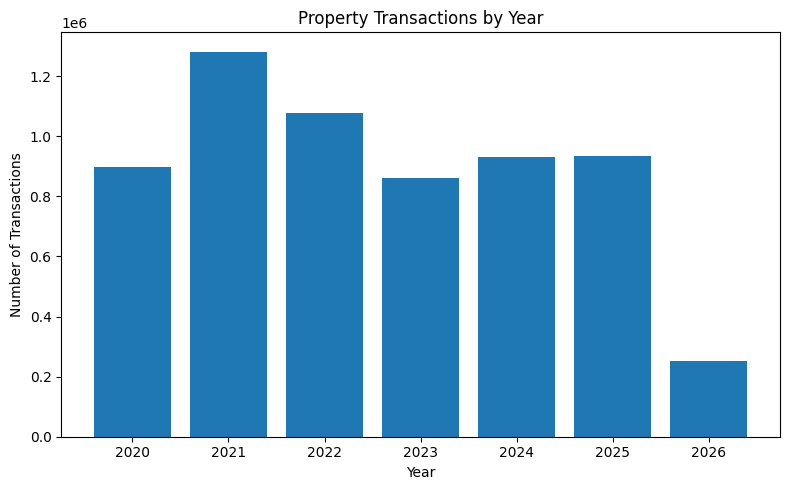

In [149]:
plt.figure(figsize=(8, 5))
plt.bar(transactions_by_year["year"], transactions_by_year["transactions"])
plt.xlabel("Year")
plt.ylabel("Number of Transactions")
plt.title("Property Transactions by Year")
plt.tight_layout()

plt.savefig(data_path + "/ppd_transactions_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [150]:
avg_price_by_year = price_paid_clean.groupby("year")["price"].mean().reset_index()

avg_price_by_year

,year,price
0,2020,375415.319957
1,2021,389504.419113
2,2022,414510.168510
3,2023,406615.002160
4,2024,399628.844425
5,2025,387536.533025
6,2026,347169.616864


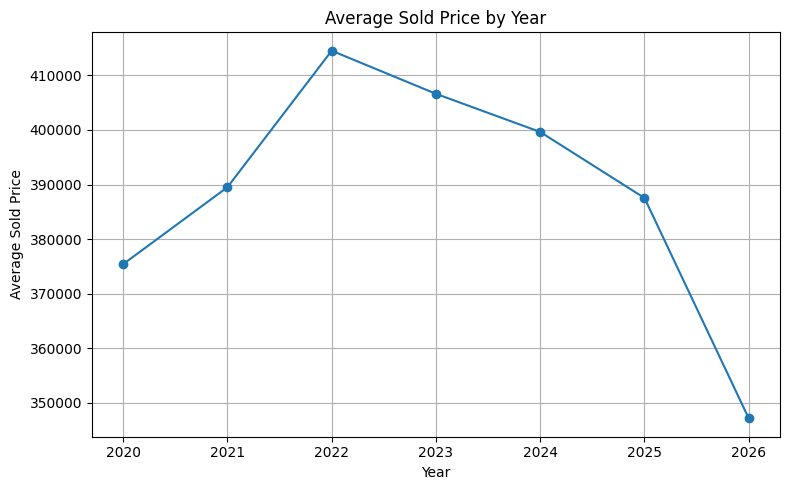

In [151]:
plt.figure(figsize=(8, 5))
plt.plot(avg_price_by_year["year"], avg_price_by_year["price"], marker="o")
plt.xlabel("Year")
plt.ylabel("Average Sold Price")
plt.title("Average Sold Price by Year")
plt.grid(True)
plt.tight_layout()

plt.savefig(data_path + "/ppd_average_price_by_year.png", dpi=300, bbox_inches="tight")
plt.show()

In [152]:
avg_price_by_property_type = (
    price_paid_clean
    .groupby("property_type_name")["price"]
    .mean()
    .reset_index()
    .sort_values("price", ascending=False)
)

avg_price_by_property_type

,property_type_name,price
2,Other,1.164372e+06
0,Detached,4.939721e+05
1,Flat,3.231098e+05
3,Semi-Detached,3.057448e+05
4,Terraced,2.823014e+05


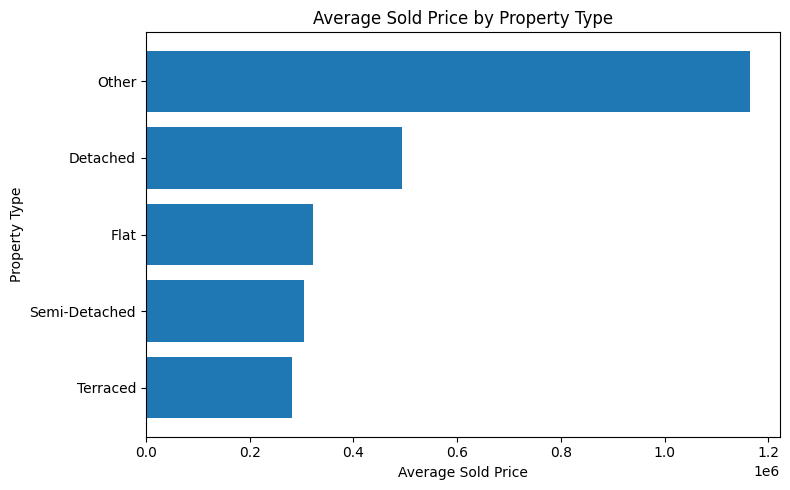

In [153]:
plt.figure(figsize=(8, 5))
plt.barh(avg_price_by_property_type["property_type_name"], avg_price_by_property_type["price"])
plt.xlabel("Average Sold Price")
plt.ylabel("Property Type")
plt.title("Average Sold Price by Property Type")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(data_path + "/ppd_average_price_by_property_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [154]:
avg_price_old_new = (
    price_paid_clean
    .groupby("old_new_name")["price"]
    .mean()
    .reset_index()
    .sort_values("price", ascending=False)
)

avg_price_old_new

,old_new_name,price
1,Old Property,394967.945372
0,New Build,381790.880261


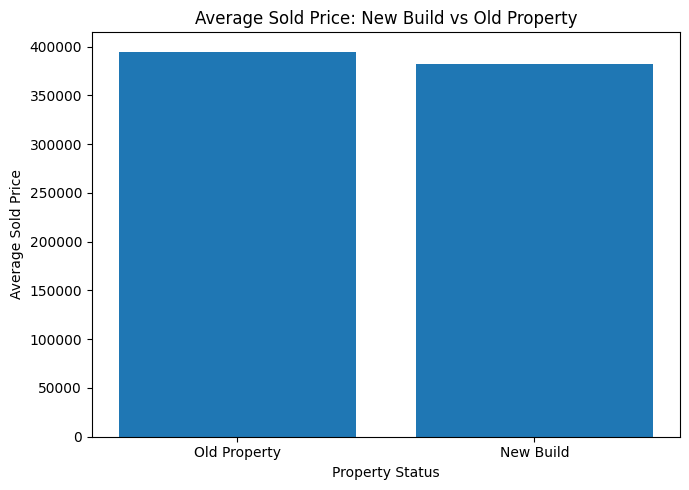

In [155]:
plt.figure(figsize=(7, 5))
plt.bar(avg_price_old_new["old_new_name"], avg_price_old_new["price"])
plt.xlabel("Property Status")
plt.ylabel("Average Sold Price")
plt.title("Average Sold Price: New Build vs Old Property")
plt.tight_layout()

plt.savefig(data_path + "/ppd_new_build_vs_old_property.png", dpi=300, bbox_inches="tight")
plt.show()

In [156]:
avg_price_duration = (
    price_paid_clean
    .groupby("duration_name")["price"]
    .mean()
    .reset_index()
    .sort_values("price", ascending=False)
)

avg_price_duration

,duration_name,price
0,Freehold,409104.599269
1,Leasehold,341930.584122


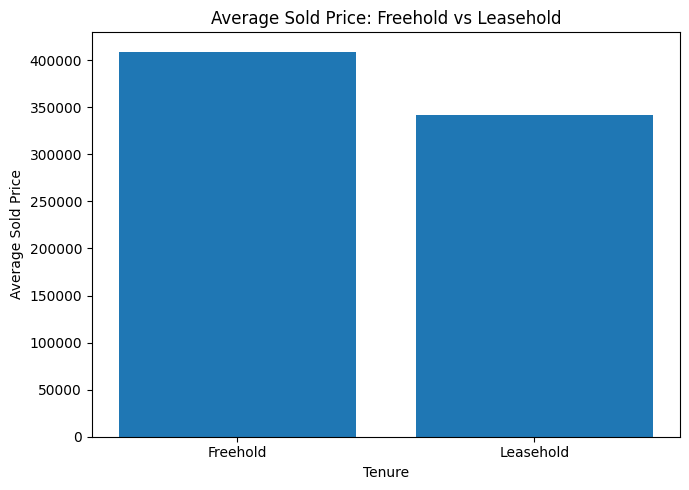

In [157]:
plt.figure(figsize=(7, 5))
plt.bar(avg_price_duration["duration_name"], avg_price_duration["price"])
plt.xlabel("Tenure")
plt.ylabel("Average Sold Price")
plt.title("Average Sold Price: Freehold vs Leasehold")
plt.tight_layout()

plt.savefig(data_path + "/ppd_freehold_vs_leasehold.png", dpi=300, bbox_inches="tight")
plt.show()

In [158]:
price_paid_clean.to_csv(data_path + "/price_paid_clean.csv", index=False)

transactions_by_year.to_csv(data_path + "/ppd_transactions_by_year.csv", index=False)
avg_price_by_year.to_csv(data_path + "/ppd_average_price_by_year.csv", index=False)
avg_price_by_property_type.to_csv(data_path + "/ppd_average_price_by_property_type.csv", index=False)
avg_price_old_new.to_csv(data_path + "/ppd_new_build_vs_old_property.csv", index=False)
avg_price_duration.to_csv(data_path + "/ppd_freehold_vs_leasehold.csv", index=False)

In [159]:
import os

dashboard_files = [
    "model_data_proposal_features.csv",
    "pipeline_regression_results.csv",
    "prediction_results.csv",
    "regional_error_analysis.csv",
    "classification_results.csv",
    "classification_prediction_results.csv",
    "price_paid_clean.csv",
    "ppd_transactions_by_year.csv",
    "ppd_average_price_by_year.csv",
    "ppd_average_price_by_property_type.csv",
    "ppd_new_build_vs_old_property.csv",
    "ppd_freehold_vs_leasehold.csv"
]

for file in dashboard_files:
    path = data_path + "/" + file
    print(file, "✅ Found" if os.path.exists(path) else "❌ Missing")

model_data_proposal_features.csv ✅ Found
pipeline_regression_results.csv ✅ Found
prediction_results.csv ✅ Found
regional_error_analysis.csv ✅ Found
classification_results.csv ✅ Found
classification_prediction_results.csv ✅ Found
price_paid_clean.csv ✅ Found
ppd_transactions_by_year.csv ✅ Found
ppd_average_price_by_year.csv ✅ Found
ppd_average_price_by_property_type.csv ✅ Found
ppd_new_build_vs_old_property.csv ✅ Found
ppd_freehold_vs_leasehold.csv ✅ Found
